# 1. EDA: Indeed Hiring Lab Sectors
I'm going to start with seasonally unadjusted first.

#### EDA means visualizing the data, finding similarities among variables, and seeing how the data interacts with itself.

In [167]:
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install plotly
%pip install numpy
%pip install nbformat

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [168]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import glob


In [169]:
# === Step 1: Load and Inspect Dataset ===
DATA_PATH = "C:\git\SwYtch-Team-Monkey\Raw_Data\Indeed_Hiring_Lab\Sectors\seasonally_unadjusted"
csv_files = glob.glob(os.path.join(DATA_PATH, "*.csv"))

dataframes = []

for file in csv_files:
    # Read each CSV file
    df_temp = pd.read_csv(file)    
    # Add a column to identify which file the data came from
    df_temp['source_file'] = os.path.basename(file)
    
    # Add to our list of dataframes
    dataframes.append(df_temp)
    
    print(f"Loaded {file}: {df_temp.shape[0]} rows, {df_temp.shape[1]} columns")

# Combine all dataframes using pd.concat()
combined_df = pd.concat(dataframes, ignore_index=True)

print(f"\nCombined dataframe shape: {combined_df.shape}")
print(f"Total rows: {len(combined_df)}")
print(f"Total columns: {len(combined_df.columns)}")


print("Data types: \n", combined_df.dtypes, "\n ---")
print("Data info: \n", combined_df.info(), "\n ---")
combined_df

Loaded C:\git\SwYtch-Team-Monkey\Raw_Data\Indeed_Hiring_Lab\Sectors\seasonally_unadjusted\accounting_admin-assist_architecture-arts+entertainment_banking+finance_childcare_civilengineering.csv: 14406 rows, 9 columns
Loaded C:\git\SwYtch-Team-Monkey\Raw_Data\Indeed_Hiring_Lab\Sectors\seasonally_unadjusted\cleaning+sanitation_community+social-service_construction_customer-service_data-analytics_dental_driving.csv: 14406 rows, 9 columns
Loaded C:\git\SwYtch-Team-Monkey\Raw_Data\Indeed_Hiring_Lab\Sectors\seasonally_unadjusted\education-instruction_electrical-engineering_food-prep+service_hospitality+tourism_human-resources_IT-infrastructure_IT-systems.csv: 14406 rows, 9 columns
Loaded C:\git\SwYtch-Team-Monkey\Raw_Data\Indeed_Hiring_Lab\Sectors\seasonally_unadjusted\industrial-engineering_installation+maintenance_legal_loading+stocking_logistic-support_management_marketing.csv: 14406 rows, 9 columns
Loaded C:\git\SwYtch-Team-Monkey\Raw_Data\Indeed_Hiring_Lab\Sectors\seasonally_unadjusted\m

<>:2: SyntaxWarning: invalid escape sequence '\g'
<>:2: SyntaxWarning: invalid escape sequence '\g'
C:\Users\rojas\AppData\Local\Temp\ipykernel_42848\1210535463.py:2: SyntaxWarning: invalid escape sequence '\g'
  DATA_PATH = "C:\git\SwYtch-Team-Monkey\Raw_Data\Indeed_Hiring_Lab\Sectors\seasonally_unadjusted"


,__typename,dateString,countryCode,countryName,sectorCode,sectorName,postingType,value,source_file
0,HiringLabSectoralPosting,2020-02-01,US,United States,accounting,Accounting,TOTAL,100.00,accounting_admin-assist_architecture-arts+ente...
1,HiringLabSectoralPosting,2020-02-01,US,United States,admin,Administrative Assistance,TOTAL,100.00,accounting_admin-assist_architecture-arts+ente...
2,HiringLabSectoralPosting,2020-02-01,US,United States,arch,Architecture,TOTAL,100.00,accounting_admin-assist_architecture-arts+ente...
3,HiringLabSectoralPosting,2020-02-01,US,United States,arts,Arts & Entertainment,TOTAL,100.00,accounting_admin-assist_architecture-arts+ente...
4,HiringLabSectoralPosting,2020-02-01,US,United States,childcare,Childcare,TOTAL,100.00,accounting_admin-assist_architecture-arts+ente...
...,...,...,...,...,...,...,...,...,...
93779,HiringLabSectoralPosting,2025-09-18,US,United States,therapy,Therapy,NEW,197.37,sports_therapy_veterinary.csv
93780,HiringLabSectoralPosting,2025-09-18,US,United States,veterinary,Veterinary,NEW,160.63,sports_therapy_veterinary.csv
93781,HiringLabSectoralPosting,2025-09-19,US,United States,sports,Sports,NEW,101.65,sports_therapy_veterinary.csv
93782,HiringLabSectoralPosting,2025-09-19,US,United States,therapy,Therapy,NEW,194.54,sports_therapy_veterinary.csv


In [170]:
#lets go ahead and get rid of anything we don't need for the time being, we also do some data integrity checks
df_cleaned = combined_df.copy()

print("=== NULL VALUES CHECK ===")
print(f"Total null values in df_cleaned: {df_cleaned.isnull().sum().sum()}")
print("\nNull values by column:")
print(df_cleaned.isnull().sum())

print("=== DUPLICATE VALUES CHECK ===")
print(f"Total duplicate rows in df_cleaned: {df_cleaned.duplicated().sum()}")

print("=== EMPTY STRINGS CHECK ===")
string_cols = df_cleaned.select_dtypes(include=['object'])
for cols in string_cols:
    empty_strings = (string_cols == '').sum()
    if any(empty_strings) > 0:
        print(f"Column {cols} has {empty_strings} empty strings")
    else:
        print(f"Column {cols} has no empty strings")

#print("=== DATA TYPES CHECK ===")
#print(df_cleaned.dtypes)

#print("=== EXTREME VALUES CHECK ===")


#We also combine the sector code and name into a single column to find more unique sectors

df_temp_sector_code_plus_name = df_cleaned['sectorCode'] + ' - ' + df_cleaned['sectorName']
df_cleaned['sectorName'] = df_temp_sector_code_plus_name

df_cleaned = df_cleaned.drop(columns=['sectorCode'])

print("There are ", len(df_cleaned['sectorName'].unique()), " unique sectors")
print("The following are the unique sectors: \n", df_cleaned['sectorName'].unique())

df_cleaned_TOTAL = df_cleaned.copy()
df_cleaned_TOTAL = df_cleaned_TOTAL[df_cleaned_TOTAL['postingType'] == 'TOTAL']
print(df_cleaned_TOTAL)
print("df_cleaned_total start date: ", df_cleaned_TOTAL['dateString'].min())
print("df_cleaned_total end date: ", df_cleaned_TOTAL['dateString'].max())

df_cleaned_NEW = df_cleaned.copy()
df_cleaned_NEW = df_cleaned_NEW[df_cleaned_NEW['postingType'] == 'NEW']
print("df_cleaned new start date: ", df_cleaned_NEW['dateString'].min())
print("df_cleaned_new end date: ", df_cleaned_NEW['dateString'].max())


=== NULL VALUES CHECK ===
Total null values in df_cleaned: 0

Null values by column:
__typename     0
dateString     0
countryCode    0
countryName    0
sectorCode     0
sectorName     0
postingType    0
value          0
source_file    0
dtype: int64
=== DUPLICATE VALUES CHECK ===
Total duplicate rows in df_cleaned: 0
=== EMPTY STRINGS CHECK ===
Column __typename has no empty strings
Column dateString has no empty strings
Column countryCode has no empty strings
Column countryName has no empty strings
Column sectorCode has no empty strings
Column sectorName has no empty strings
Column postingType has no empty strings
Column source_file has no empty strings
There are  45  unique sectors
The following are the unique sectors: 
 ['accounting - Accounting' 'admin - Administrative Assistance'
 'arch - Architecture' 'arts - Arts & Entertainment'
 'childcare - Childcare' 'engcivil - Civil Engineering'
 'finance - Banking & Finance' 'construction - Construction'
 'customer - Customer Service' 'd

In [171]:
df_cleaned_NEW

,__typename,dateString,countryCode,countryName,sectorName,postingType,value,source_file
92610,HiringLabSectoralPosting,2024-08-24,US,United States,veterinary - Veterinary,NEW,161.88,sports_therapy_veterinary.csv
92611,HiringLabSectoralPosting,2024-08-25,US,United States,sports - Sports,NEW,145.31,sports_therapy_veterinary.csv
92612,HiringLabSectoralPosting,2024-08-25,US,United States,therapy - Therapy,NEW,210.45,sports_therapy_veterinary.csv
92613,HiringLabSectoralPosting,2024-08-25,US,United States,veterinary - Veterinary,NEW,161.36,sports_therapy_veterinary.csv
92614,HiringLabSectoralPosting,2024-08-26,US,United States,sports - Sports,NEW,145.37,sports_therapy_veterinary.csv
...,...,...,...,...,...,...,...,...
93779,HiringLabSectoralPosting,2025-09-18,US,United States,therapy - Therapy,NEW,197.37,sports_therapy_veterinary.csv
93780,HiringLabSectoralPosting,2025-09-18,US,United States,veterinary - Veterinary,NEW,160.63,sports_therapy_veterinary.csv
93781,HiringLabSectoralPosting,2025-09-19,US,United States,sports - Sports,NEW,101.65,sports_therapy_veterinary.csv
93782,HiringLabSectoralPosting,2025-09-19,US,United States,therapy - Therapy,NEW,194.54,sports_therapy_veterinary.csv


In [172]:
df_cleaned_TOTAL

,__typename,dateString,countryCode,countryName,sectorName,postingType,value,source_file
0,HiringLabSectoralPosting,2020-02-01,US,United States,accounting - Accounting,TOTAL,100.00,accounting_admin-assist_architecture-arts+ente...
1,HiringLabSectoralPosting,2020-02-01,US,United States,admin - Administrative Assistance,TOTAL,100.00,accounting_admin-assist_architecture-arts+ente...
2,HiringLabSectoralPosting,2020-02-01,US,United States,arch - Architecture,TOTAL,100.00,accounting_admin-assist_architecture-arts+ente...
3,HiringLabSectoralPosting,2020-02-01,US,United States,arts - Arts & Entertainment,TOTAL,100.00,accounting_admin-assist_architecture-arts+ente...
4,HiringLabSectoralPosting,2020-02-01,US,United States,childcare - Childcare,TOTAL,100.00,accounting_admin-assist_architecture-arts+ente...
...,...,...,...,...,...,...,...,...
92605,HiringLabSectoralPosting,2025-09-18,US,United States,therapy - Therapy,TOTAL,195.99,sports_therapy_veterinary.csv
92606,HiringLabSectoralPosting,2025-09-18,US,United States,veterinary - Veterinary,TOTAL,148.98,sports_therapy_veterinary.csv
92607,HiringLabSectoralPosting,2025-09-19,US,United States,sports - Sports,TOTAL,153.11,sports_therapy_veterinary.csv
92608,HiringLabSectoralPosting,2025-09-19,US,United States,therapy - Therapy,TOTAL,195.85,sports_therapy_veterinary.csv


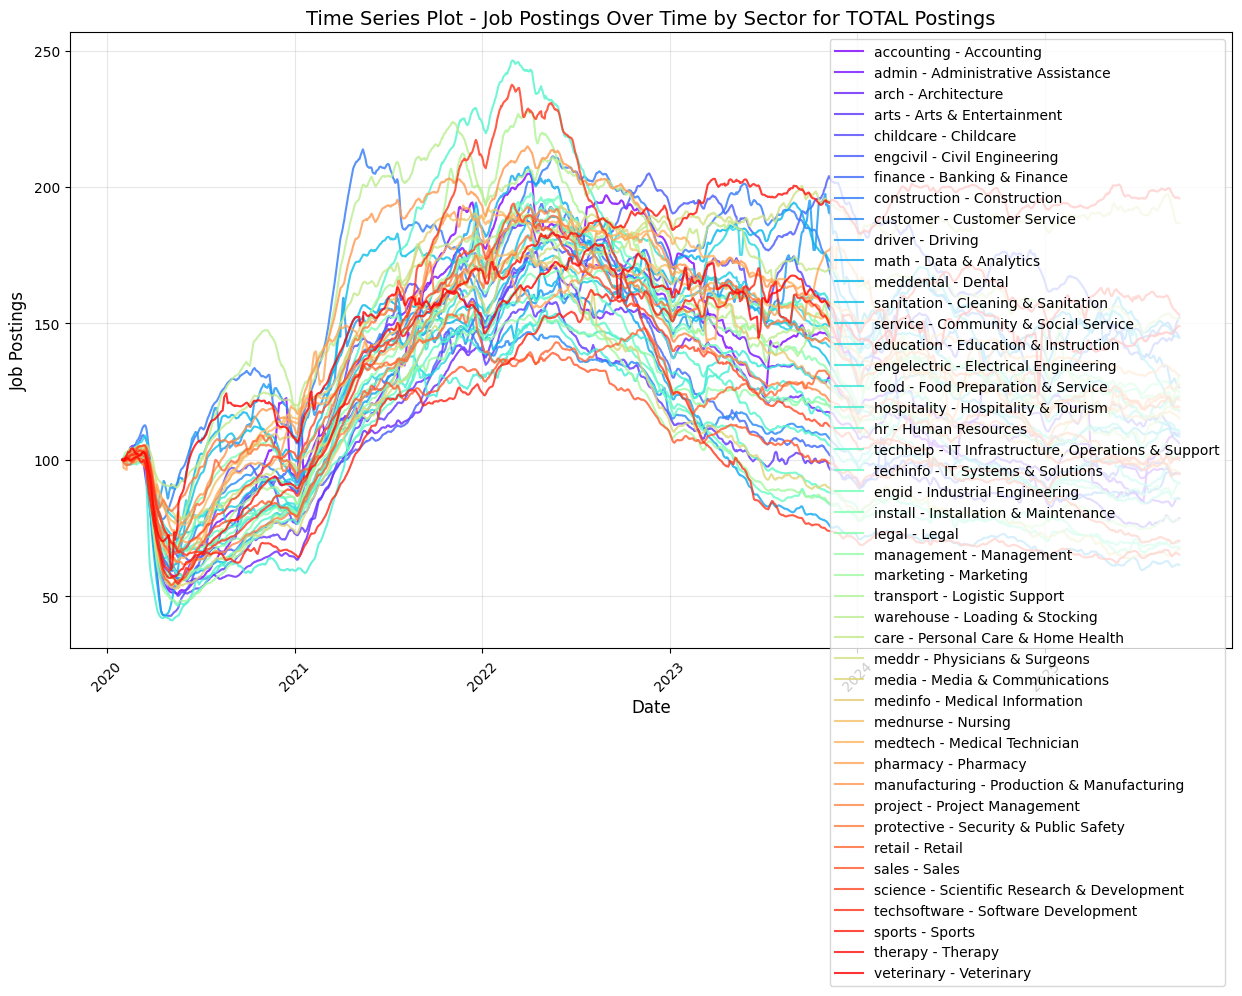

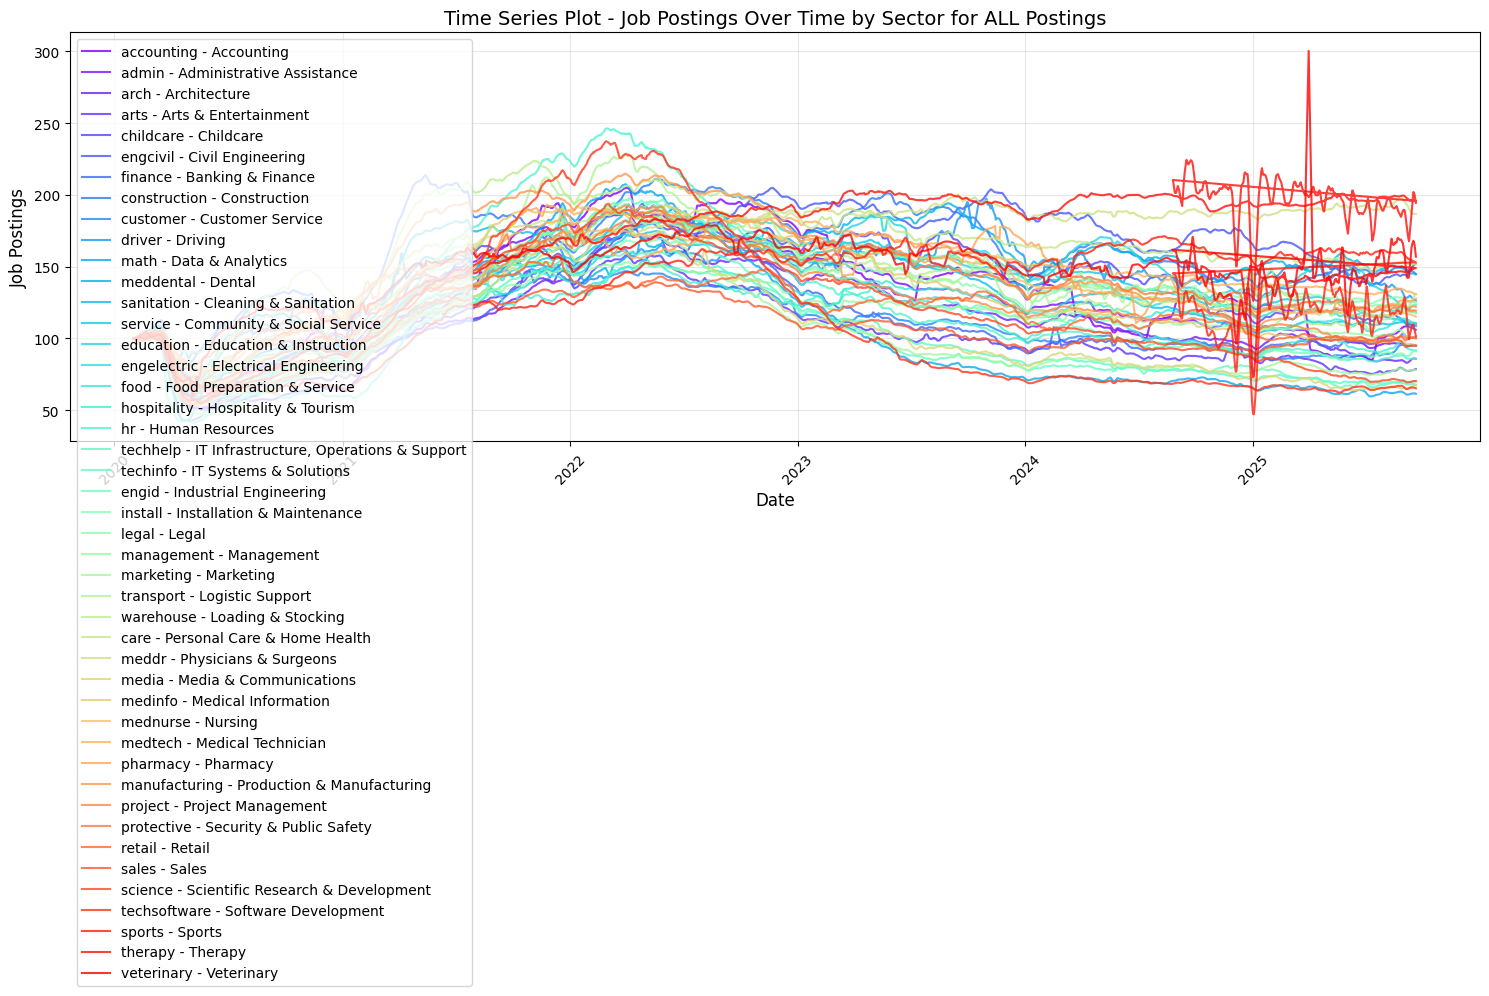

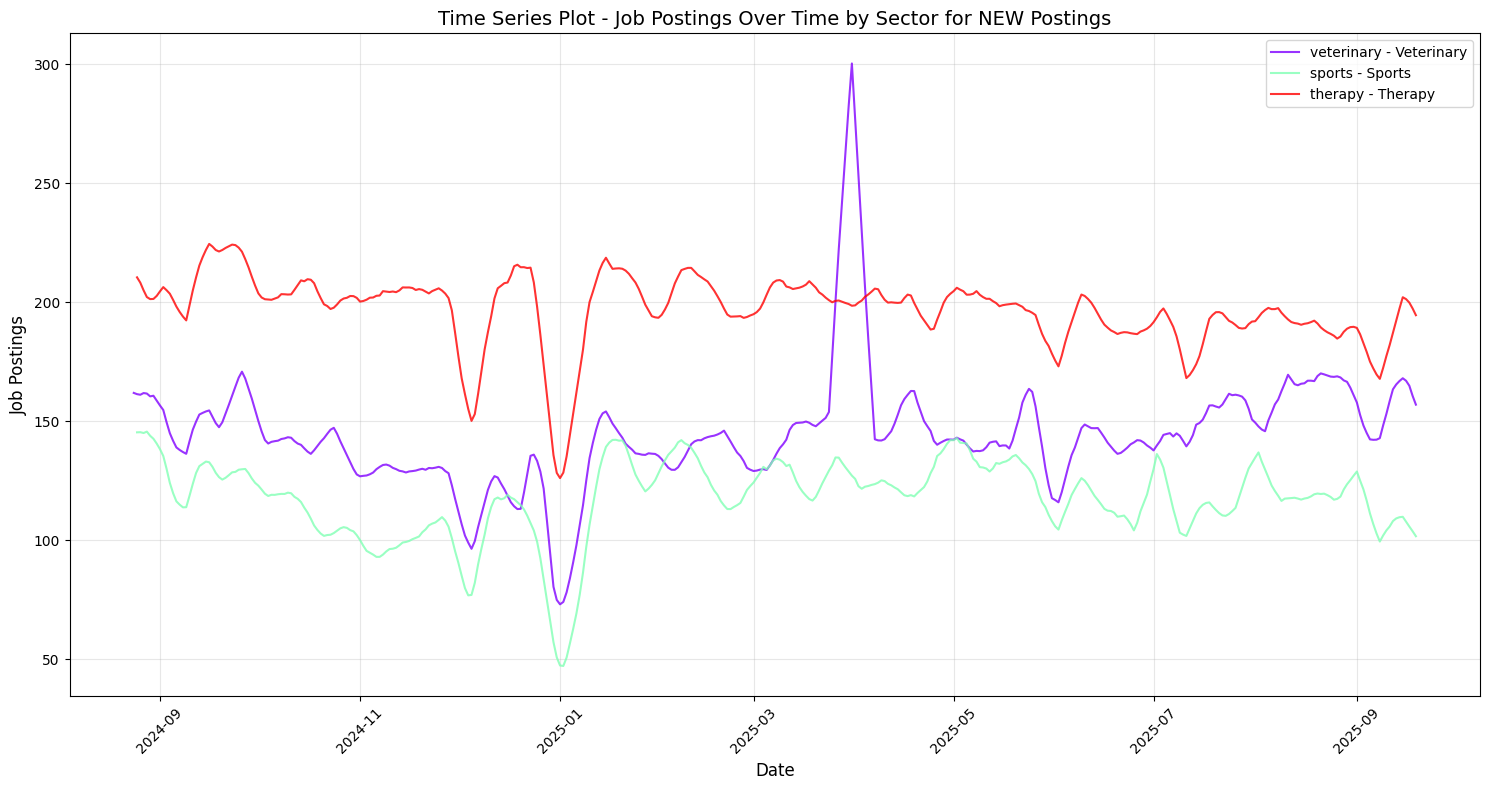

In [173]:
# Now let's create a simple time-series plot
# First, we need to convert the dateString column to a datetime object using pd.to_datetime
#-----------------------------------------------
df_cleaned_TOTAL['dateString'] = pd.to_datetime(df_cleaned_TOTAL['dateString'])

# Set up the plot
plt.figure(figsize=(15, 8))

sectors = df_cleaned_TOTAL['sectorName'].unique()
colors = plt.cm.rainbow(np.linspace(0, 1, len(sectors)))

for i, sector in enumerate(sectors):
    sector_data = df_cleaned_TOTAL[df_cleaned_TOTAL['sectorName'] == sector]
    plt.plot(sector_data['dateString'], sector_data['value'], label=sector, color=colors[i], linewidth=1.5, alpha=0.8)

plt.title('Time Series Plot - Job Postings Over Time by Sector for TOTAL Postings', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Job Postings', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=10) 

#-------------------------------------------------------------------------


df_cleaned['dateString'] = pd.to_datetime(df_cleaned['dateString'])

# Set up the plot
plt.figure(figsize=(15, 8))

sectors = df_cleaned['sectorName'].unique()
colors = plt.cm.rainbow(np.linspace(0, 1, len(sectors)))

for i, sector in enumerate(sectors):
    sector_data = df_cleaned[df_cleaned['sectorName'] == sector]
    plt.plot(sector_data['dateString'], sector_data['value'], label=sector, color=colors[i], linewidth=1.5, alpha=0.8)

plt.title('Time Series Plot - Job Postings Over Time by Sector for ALL Postings', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Job Postings', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()
#-----------------------------------------------
df_cleaned_NEW['dateString'] = pd.to_datetime(df_cleaned_NEW['dateString'])

# Set up the plot
plt.figure(figsize=(15, 8))

sectors = df_cleaned_NEW['sectorName'].unique()
colors = plt.cm.rainbow(np.linspace(0, 1, len(sectors)))

for i, sector in enumerate(sectors):
    sector_data = df_cleaned_NEW[df_cleaned_NEW['sectorName'] == sector]
    plt.plot(sector_data['dateString'], sector_data['value'], label=sector, color=colors[i], linewidth=1.5, alpha=0.8)

plt.title('Time Series Plot - Job Postings Over Time by Sector for NEW Postings', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Job Postings', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()


In [174]:
# based on the new and total datasets, there is overlap in timing for values between new and total datasets
# gotta average them out to properly show the full graph
# planning on doing this later, for now keep moving
# df_cleaned_NEW_sorted = df_cleaned_NEW.sort_values('dateString').reset_index(drop=True)
# df_cleaned_NEW_sorted

# df_cleaned_TOTAL_sorted = df_cleaned_TOTAL.sort_values('dateString').reset_index(drop=True)

# df_cleaned_TOTAL['da']

# print("df_cleaned_NEW_sorted:")
# print(f"Start date: {df_cleaned_NEW_sorted['dateString'].min()}")
# print(f"End date: {df_cleaned_NEW_sorted['dateString'].max()}")
# print(f"Shape: {df_cleaned_NEW_sorted.shape}")

# print("\ndf_cleaned_TOTAL_sorted:")
# print(f"Start date: {df_cleaned_TOTAL_sorted['dateString'].min()}")
# print(f"End date: {df_cleaned_TOTAL_sorted['dateString'].max()}")
# print(f"Shape: {df_cleaned_TOTAL_sorted.shape}")

# df_cleaned_NEW_and_TOTAL_avg_start_date = df_cleaned_NEW_sorted['dateString'].min()
# print(df_cleaned_NEW_and_TOTAL_avg_start_date)

# target_sectors = ['veterinary - Veterinary', 'sports - Sports', 'therapy - Therapy']

# # all of the data in df_cleaned_NEW contians the targets, so we can just make a copy of the dataframe as is
# df_cleaned_NEW_sorted_copy = df_cleaned_NEW_sorted.copy()

# df_cleaned_TOTAL_targets = df_cleaned_TOTAL_sorted[df_cleaned_TOTAL_sorted['sectorName'].isin(target_sectors)].copy()

# df_TOTAL_target_from_min = df_cleaned_TOTAL_targets[df_cleaned_TOTAL_targets['dateString'] >= df_cleaned_NEW_and_TOTAL_avg_start_date]

# print(f"TOTAL data from min date shape: {df_TOTAL_target_from_min.shape}")
# df_TOTAL_target_from_min

# df_cleaned_ALL = df_cleaned_TOTAL


In [175]:
# === Step 4: Create Box Plots ===
# Let's create box plots to understand the distribution of our data
#until we avg the NEW and TOTAL vals, we're just going to use TOTAL

# First, let's look at the basic statistics of our value column
print("Basic Statistics for 'value' column for TOTAL Postings:")
print(df_cleaned_TOTAL['value'].describe())
print(f"\nTotal number of observations: {len(df_cleaned_TOTAL)}")
print(f"Unique posting types: {df_cleaned_TOTAL['postingType'].unique()}")
print("-----------------------------------------------")
print("Basic Statistics for 'value' column for ALL Postings:")
print(df_cleaned['value'].describe())
print(f"\nTotal number of observations: {len(df_cleaned)}")
print(f"Unique posting types: {df_cleaned['postingType'].unique()}")
print("-----------------------------------------------")
print("Basic Statistics for 'value' column for NEW Postings:")
print(df_cleaned_NEW['value'].describe())
print(f"\nTotal number of observations: {len(df_cleaned_NEW)}")
print(f"Unique posting types: {df_cleaned_NEW['postingType'].unique()}")







Basic Statistics for 'value' column for TOTAL Postings:
count    92610.000000
mean       129.598721
std         38.129855
min         41.180000
25%         99.780000
50%        129.110000
75%        158.510000
max        246.390000
Name: value, dtype: float64

Total number of observations: 92610
Unique posting types: ['TOTAL']
-----------------------------------------------
Basic Statistics for 'value' column for ALL Postings:
count    93784.000000
mean       129.890842
std         38.216013
min         41.180000
25%         99.940000
50%        129.460000
75%        158.762500
max        300.340000
Name: value, dtype: float64

Total number of observations: 93784
Unique posting types: ['TOTAL' 'NEW']
-----------------------------------------------
Basic Statistics for 'value' column for NEW Postings:
count    1174.000000
mean      152.934557
std        37.984528
min        47.130000
25%       124.675000
50%       142.320000
75%       192.232500
max       300.340000
Name: value, dtype: 

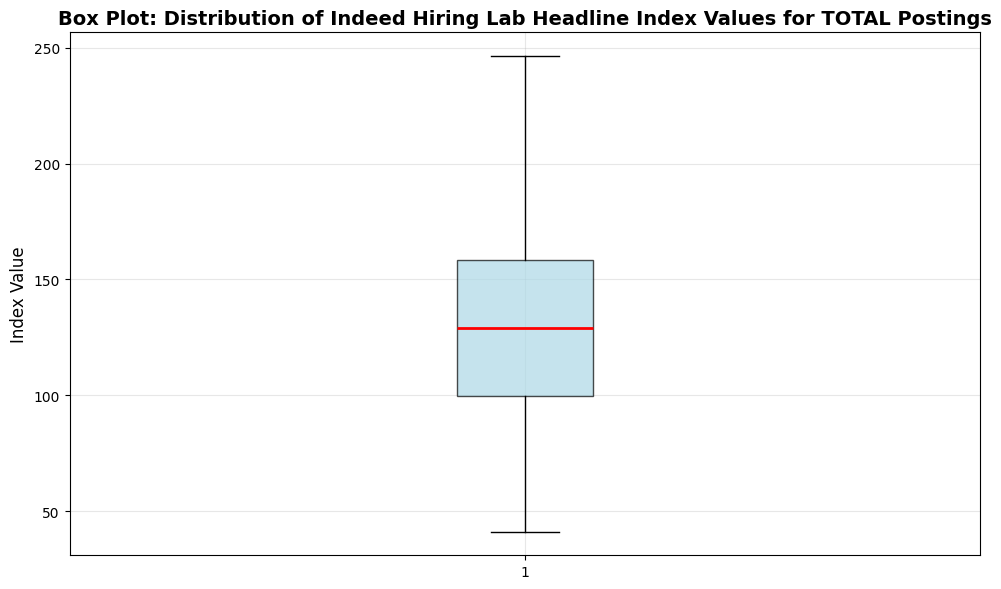

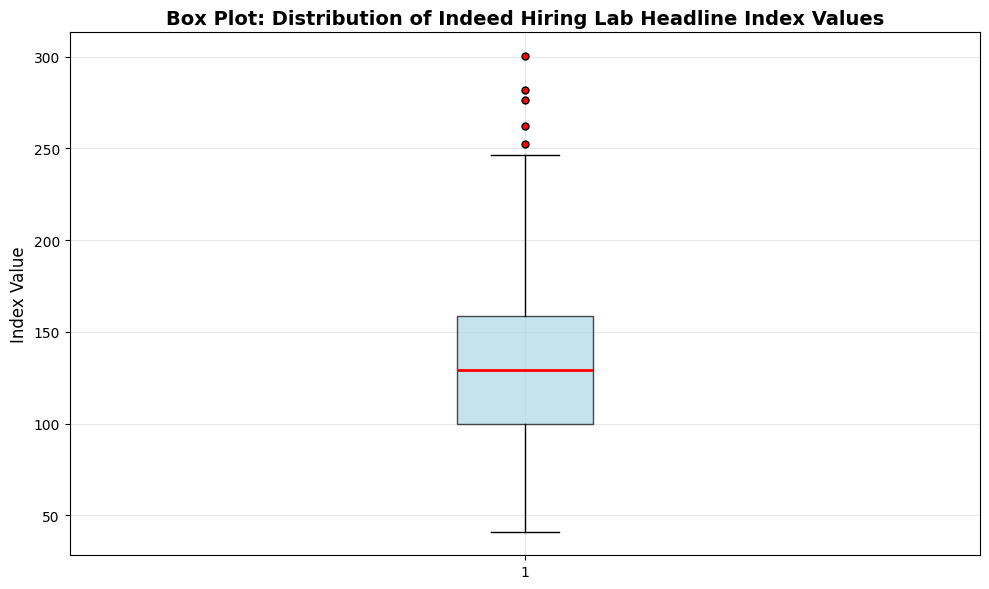

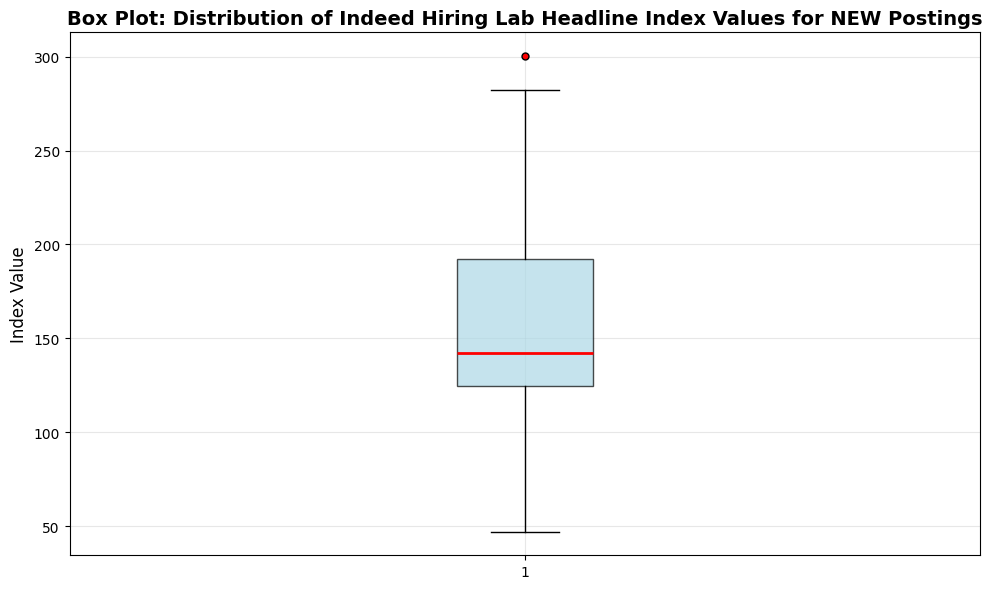

In [176]:
# Create a basic box plot for the value column: TOTAL Postings
plt.figure(figsize=(10, 6))
plt.boxplot(df_cleaned_TOTAL['value'], patch_artist=True, 
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2),
            flierprops=dict(marker='o', markerfacecolor='red', markersize=5))

plt.title('Box Plot: Distribution of Indeed Hiring Lab Headline Index Values for TOTAL Postings', 
          fontsize=14, fontweight='bold')
plt.ylabel('Index Value', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
#-----------------------------------------------


# Create a basic box plot for the value column: ALL Postings
plt.figure(figsize=(10, 6))
plt.boxplot(df_cleaned['value'], patch_artist=True, 
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2),
            flierprops=dict(marker='o', markerfacecolor='red', markersize=5))

plt.title('Box Plot: Distribution of Indeed Hiring Lab Headline Index Values', 
          fontsize=14, fontweight='bold')
plt.ylabel('Index Value', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
#-----------------------------------------------
# Create a basic box plot for the value column: NEW Postings
plt.figure(figsize=(10, 6))
plt.boxplot(df_cleaned_NEW['value'], patch_artist=True, 
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2),
            flierprops=dict(marker='o', markerfacecolor='red', markersize=5))

plt.title('Box Plot: Distribution of Indeed Hiring Lab Headline Index Values for NEW Postings', 
          fontsize=14, fontweight='bold')
plt.ylabel('Index Value', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
#-----------------------------------------------


In [177]:
# Create time-based box plots (monthly or yearly distributions)
# First, let's convert the dateString to datetime and extract time components
print("-----------------------------------------------")

df_time_TOTAL = df_cleaned_TOTAL.copy()
df_time_TOTAL['dateString'] = pd.to_datetime(df_time_TOTAL['dateString'])
df_time_TOTAL['year'] = df_time_TOTAL['dateString'].dt.year
df_time_TOTAL['month'] = df_time_TOTAL['dateString'].dt.month
df_time_TOTAL['month_name'] = df_time_TOTAL['dateString'].dt.month_name()

print("Date range in the TOTAL Postings data:")
print(f"From: {df_time_TOTAL['dateString'].min()}")
print(f"To: {df_time_TOTAL['dateString'].max()}")
print(f"Number of years: {df_time_TOTAL['year'].nunique()}")
print(f"Years: {sorted(df_time_TOTAL['year'].unique())}")
print("-----------------------------------------------")

df_time = df_cleaned.copy()
df_time['dateString'] = pd.to_datetime(df_time['dateString'])

# Extract year and month for time-based analysis
df_time['year'] = df_time['dateString'].dt.year
df_time['month'] = df_time['dateString'].dt.month
df_time['month_name'] = df_time['dateString'].dt.month_name()

print("Date range in the ALL Postings data:")
print(f"From: {df_time['dateString'].min()}")
print(f"To: {df_time['dateString'].max()}")
print(f"Number of years: {df_time['year'].nunique()}")
print(f"Years: {sorted(df_time['year'].unique())}")
print("-----------------------------------------------")

df_time_NEW = df_cleaned_NEW.copy()
df_time_NEW['dateString'] = pd.to_datetime(df_time_NEW['dateString'])
df_time_NEW['year'] = df_time_NEW['dateString'].dt.year
df_time_NEW['month'] = df_time_NEW['dateString'].dt.month
df_time_NEW['month_name'] = df_time_NEW['dateString'].dt.month_name()

print("Date range in the NEW Postings data:")
print(f"From: {df_time_NEW['dateString'].min()}")
print(f"To: {df_time_NEW['dateString'].max()}")
print(f"Number of years: {df_time_NEW['year'].nunique()}")
print(f"Years: {sorted(df_time_NEW['year'].unique())}")




-----------------------------------------------
Date range in the TOTAL Postings data:
From: 2020-02-01 00:00:00
To: 2025-09-19 00:00:00
Number of years: 6
Years: [np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]
-----------------------------------------------
Date range in the ALL Postings data:
From: 2020-02-01 00:00:00
To: 2025-09-19 00:00:00
Number of years: 6
Years: [np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]
-----------------------------------------------
Date range in the NEW Postings data:
From: 2024-08-24 00:00:00
To: 2025-09-19 00:00:00
Number of years: 2
Years: [np.int32(2024), np.int32(2025)]


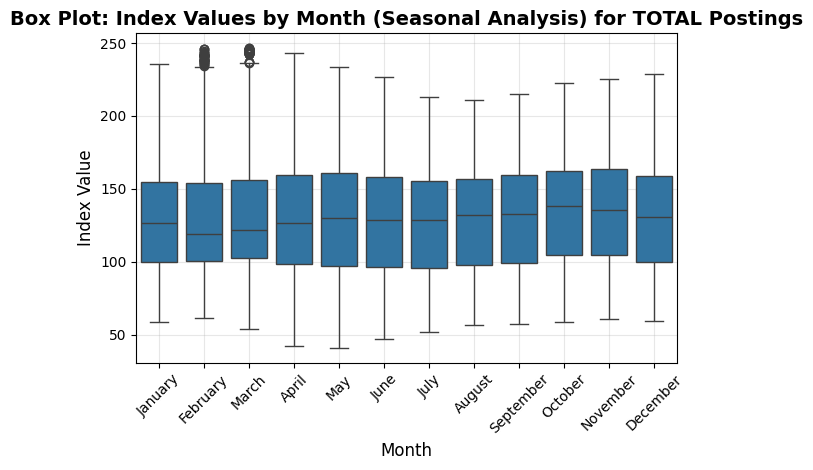

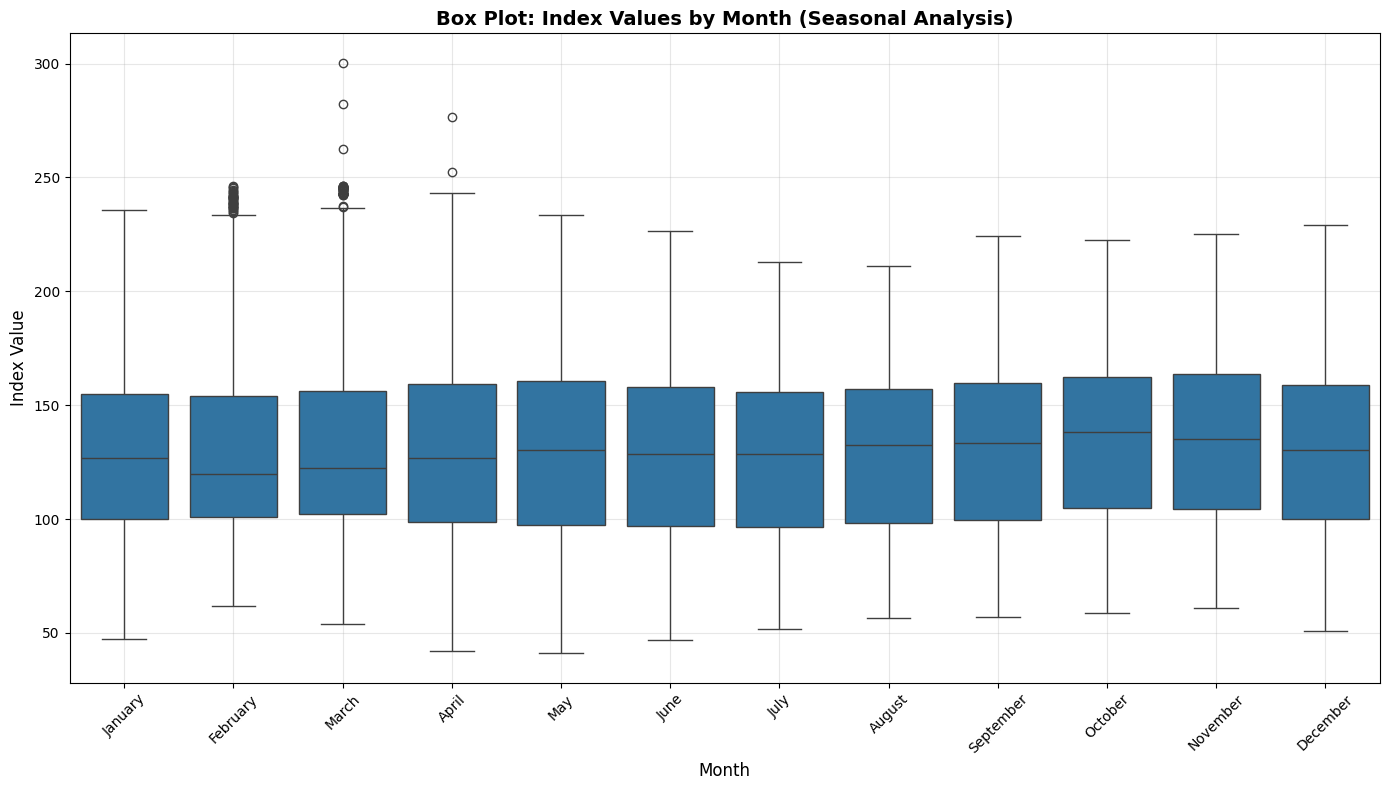

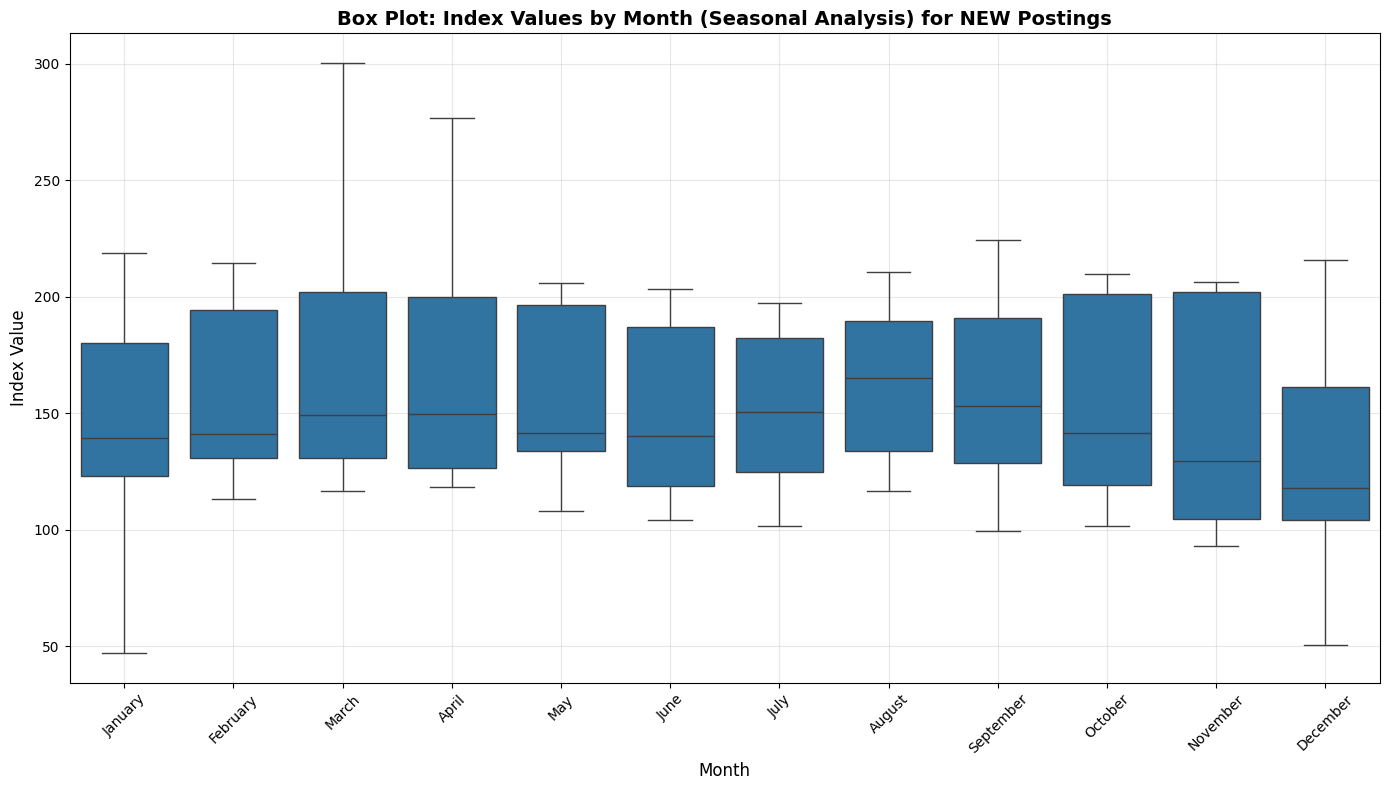

<Figure size 1400x800 with 0 Axes>

<Figure size 1400x800 with 0 Axes>

In [178]:
# Create box plots by month to see seasonal patterns
df_time_TOTAL['month_name'] = pd.Categorical(df_time_TOTAL['month_name'], categories=month_order, ordered=True)

sns.boxplot(data=df_time_TOTAL, x='month_name', y='value')
plt.title('Box Plot: Index Values by Month (Seasonal Analysis) for TOTAL Postings', fontsize=14, fontweight='bold')
plt.ylabel('Index Value', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
#-----------------------------------------------

plt.figure(figsize=(14, 8))

# Order months properly
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
df_time['month_name'] = pd.Categorical(df_time['month_name'], categories=month_order, ordered=True)


sns.boxplot(data=df_time, x='month_name', y='value')
plt.title('Box Plot: Index Values by Month (Seasonal Analysis)', fontsize=14, fontweight='bold')
plt.ylabel('Index Value', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
#-----------------------------------------------
plt.figure(figsize=(14, 8))
df_time_NEW['month_name'] = pd.Categorical(df_time_NEW['month_name'], categories=month_order, ordered=True)

sns.boxplot(data=df_time_NEW, x='month_name', y='value')
plt.title('Box Plot: Index Values by Month (Seasonal Analysis) for NEW Postings', fontsize=14, fontweight='bold')
plt.ylabel('Index Value', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.figure(figsize=(14, 8))


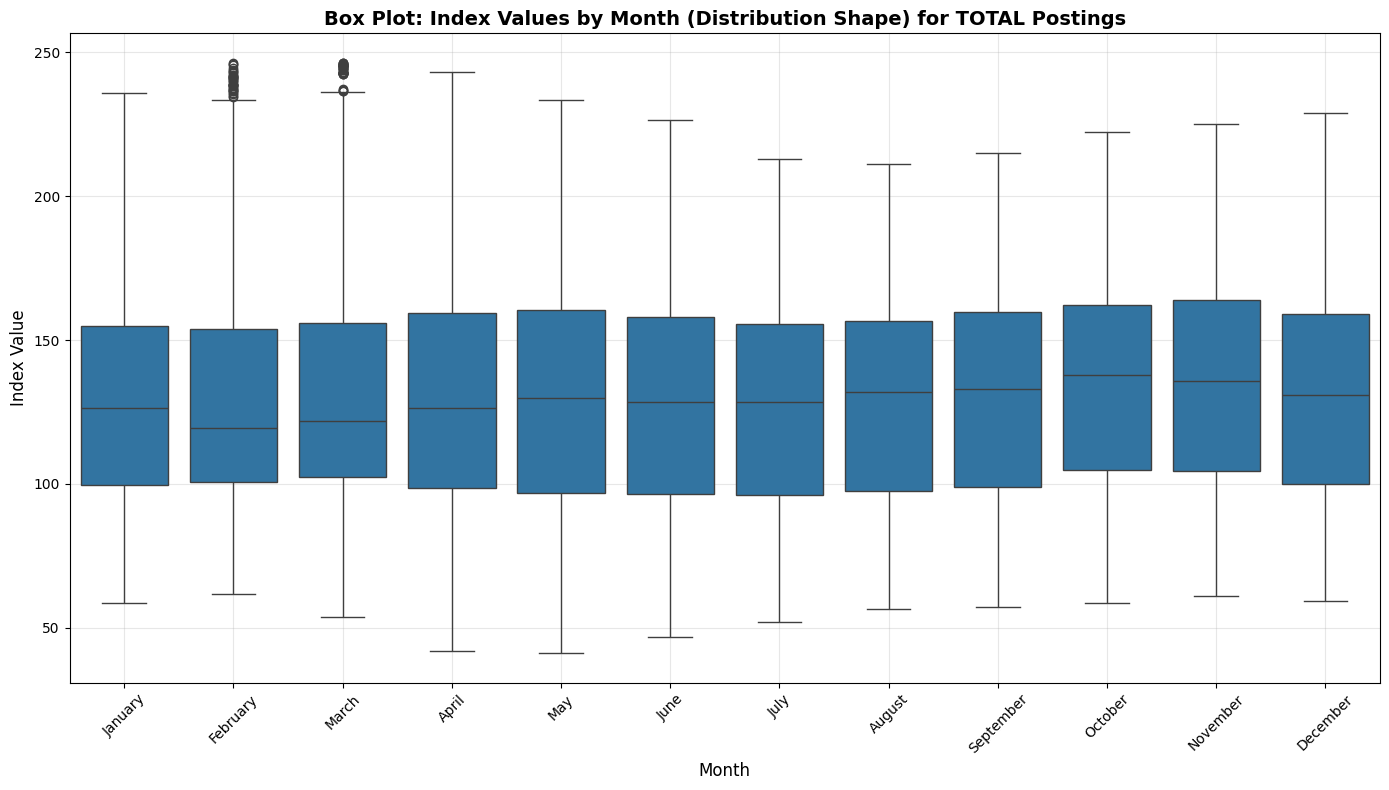

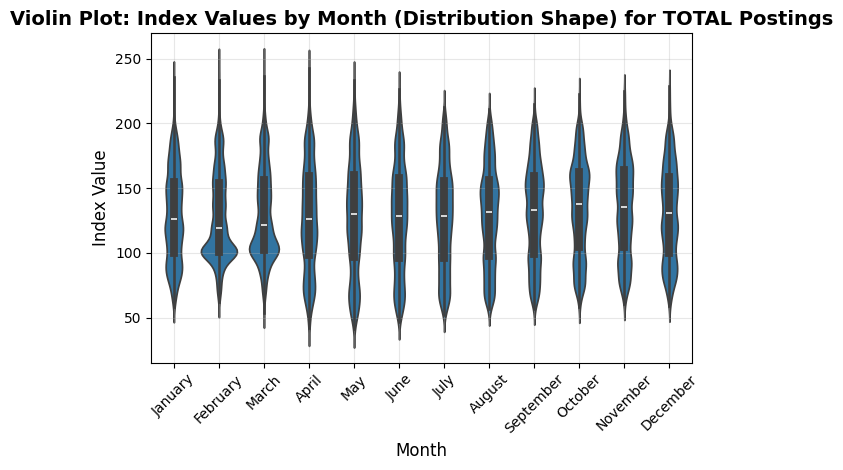

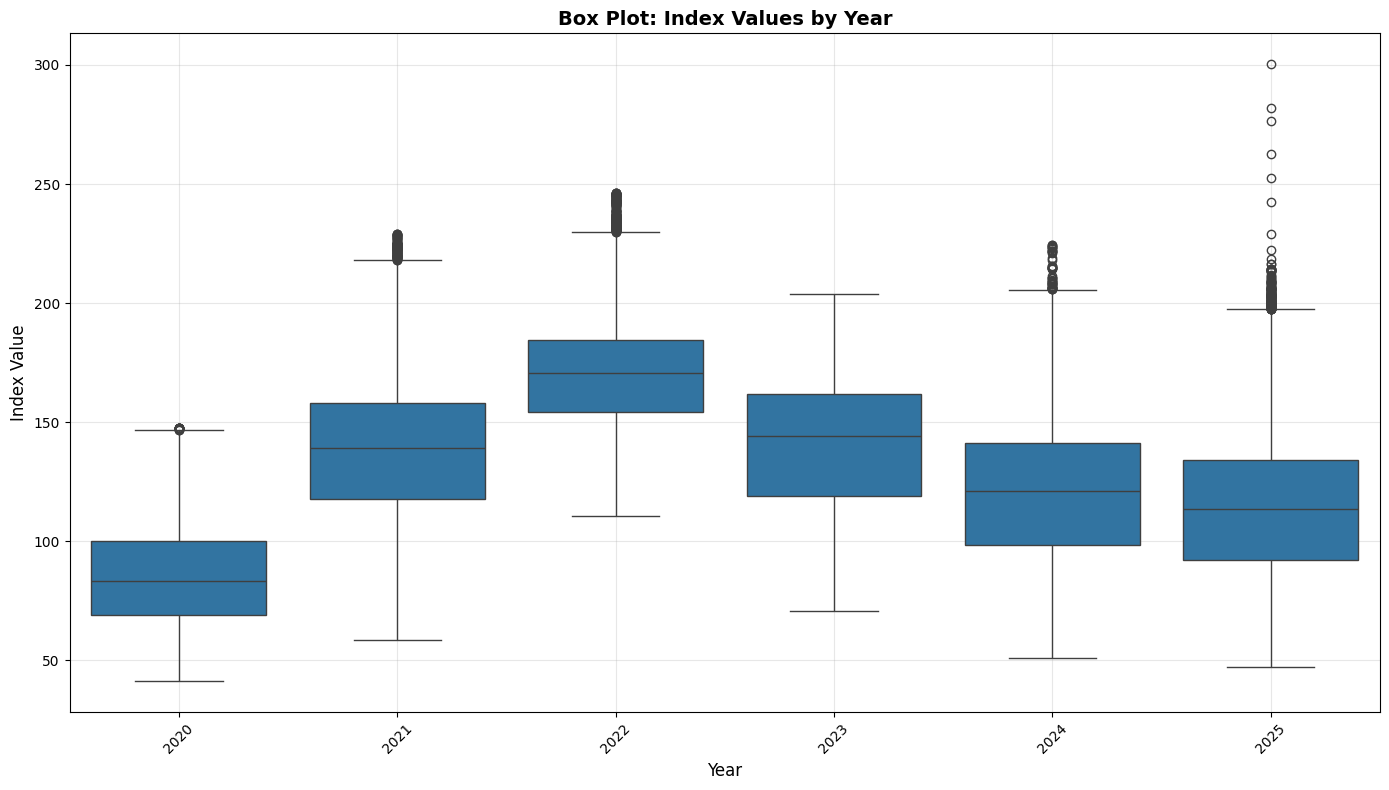

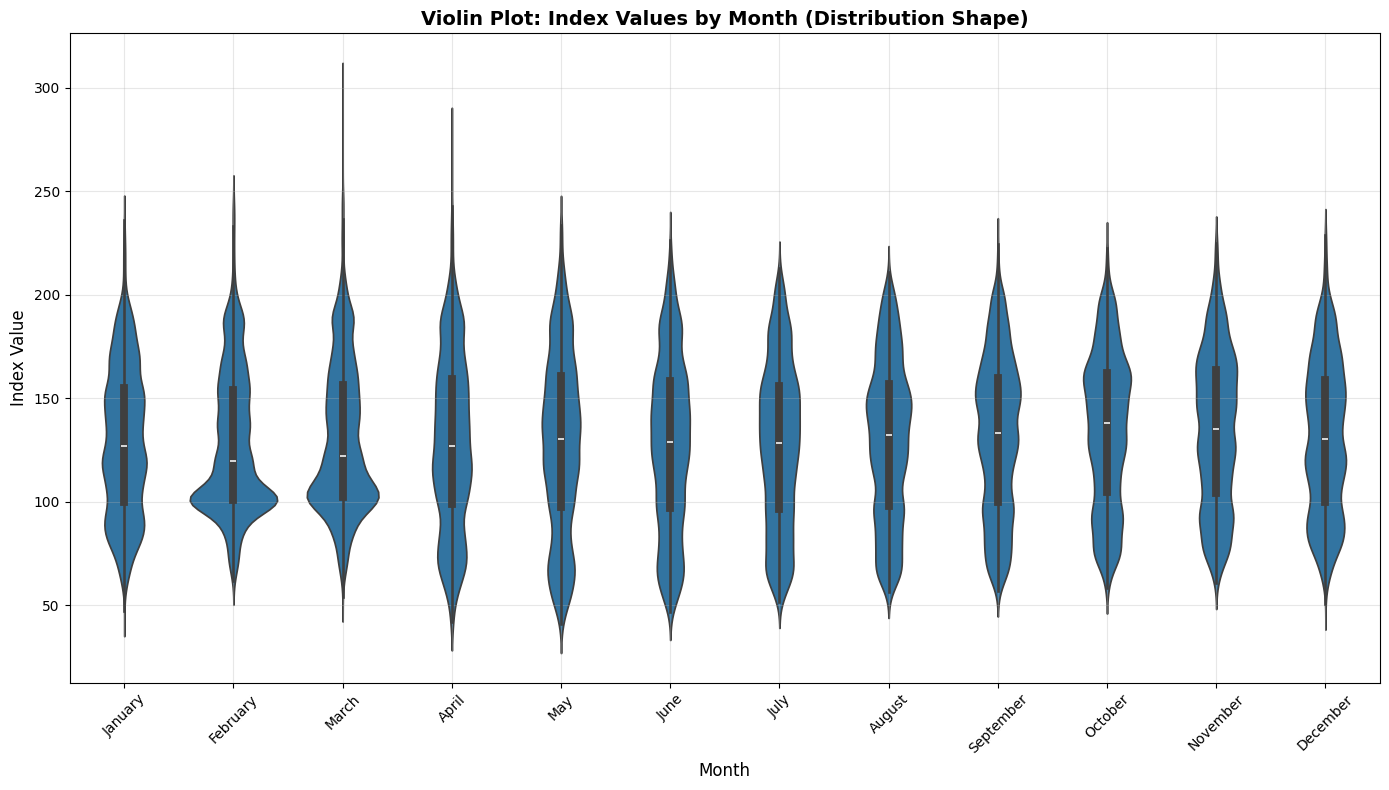

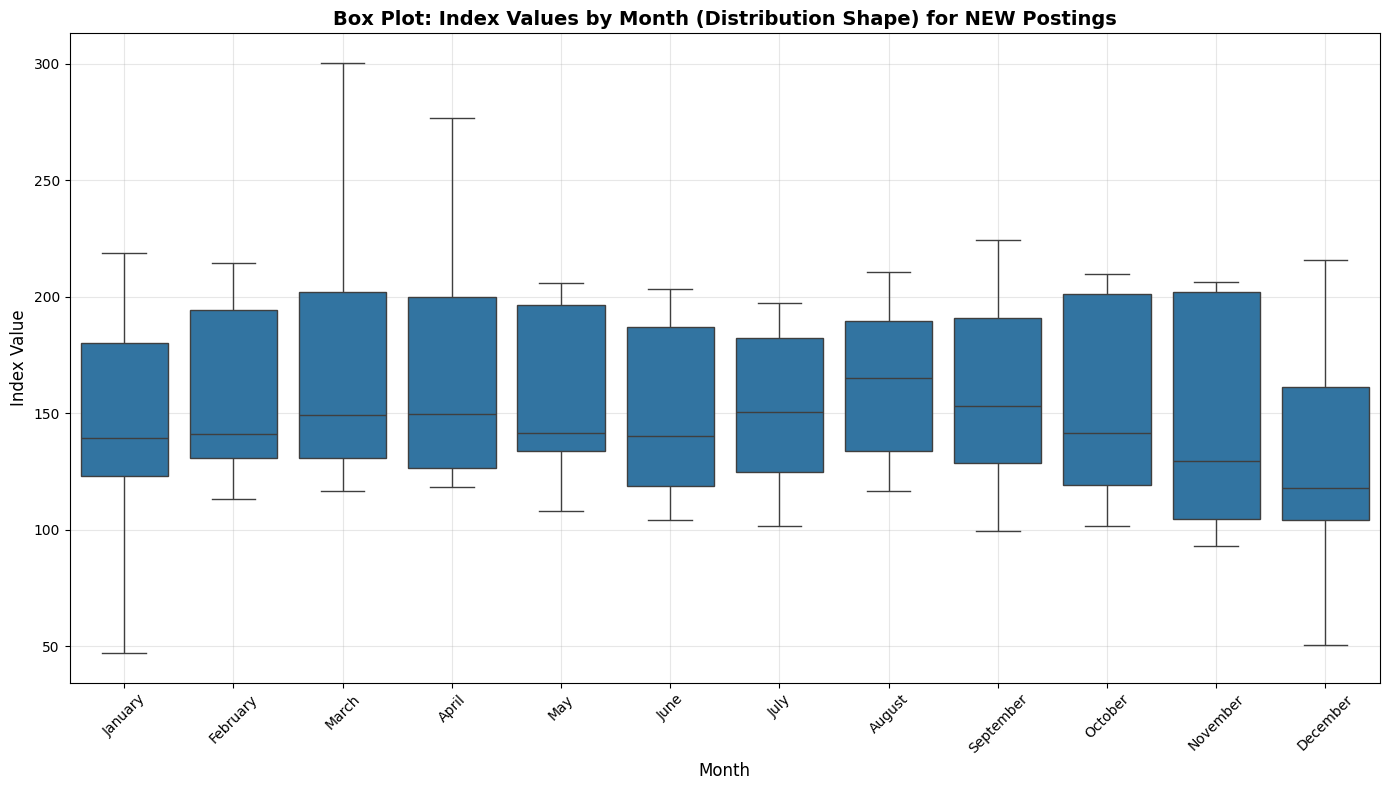

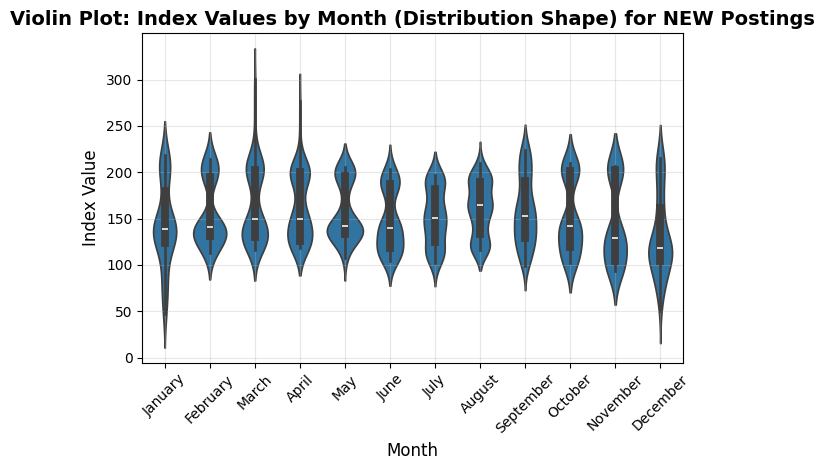

In [179]:
# Create box plots by year to see yearly trends
plt.figure(figsize=(14, 8))
sns.boxplot(data=df_time_TOTAL, x='month_name', y='value')
plt.title('Box Plot: Index Values by Month (Distribution Shape) for TOTAL Postings', fontsize=14, fontweight='bold')
plt.ylabel('Index Value', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

sns.violinplot(data=df_time_TOTAL, x='month_name', y='value')
plt.title('Violin Plot: Index Values by Month (Distribution Shape) for TOTAL Postings', fontsize=14, fontweight='bold')
plt.ylabel('Index Value', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
#-----------------------------------------------
plt.figure(figsize=(14, 8))
sns.boxplot(data=df_time, x='year', y='value')
plt.title('Box Plot: Index Values by Year', fontsize=14, fontweight='bold')
plt.ylabel('Index Value', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Create a violin plot for comparison (shows distribution shape better)
plt.figure(figsize=(14, 8))
sns.violinplot(data=df_time, x='month_name', y='value')
plt.title('Violin Plot: Index Values by Month (Distribution Shape)', fontsize=14, fontweight='bold')
plt.ylabel('Index Value', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
#-----------------------------------------------
plt.figure(figsize=(14, 8))
sns.boxplot(data=df_time_NEW, x='month_name', y='value')
plt.title('Box Plot: Index Values by Month (Distribution Shape) for NEW Postings', fontsize=14, fontweight='bold')
plt.ylabel('Index Value', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

sns.violinplot(data=df_time_NEW, x='month_name', y='value')
plt.title('Violin Plot: Index Values by Month (Distribution Shape) for NEW Postings', fontsize=14, fontweight='bold')
plt.ylabel('Index Value', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#-----------------------------------------------------------





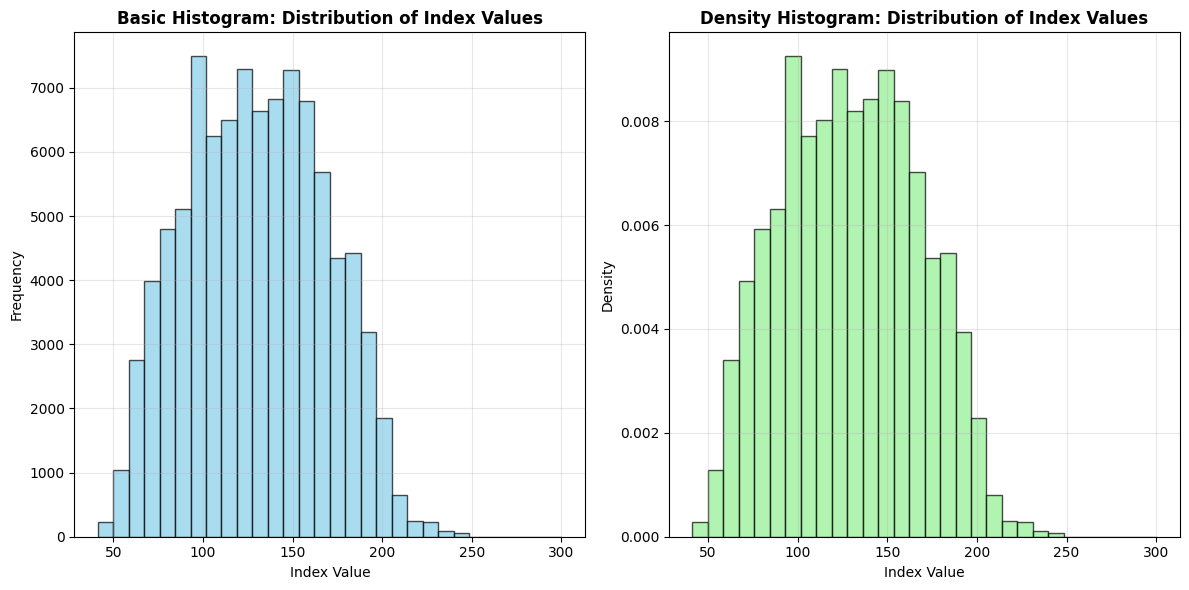

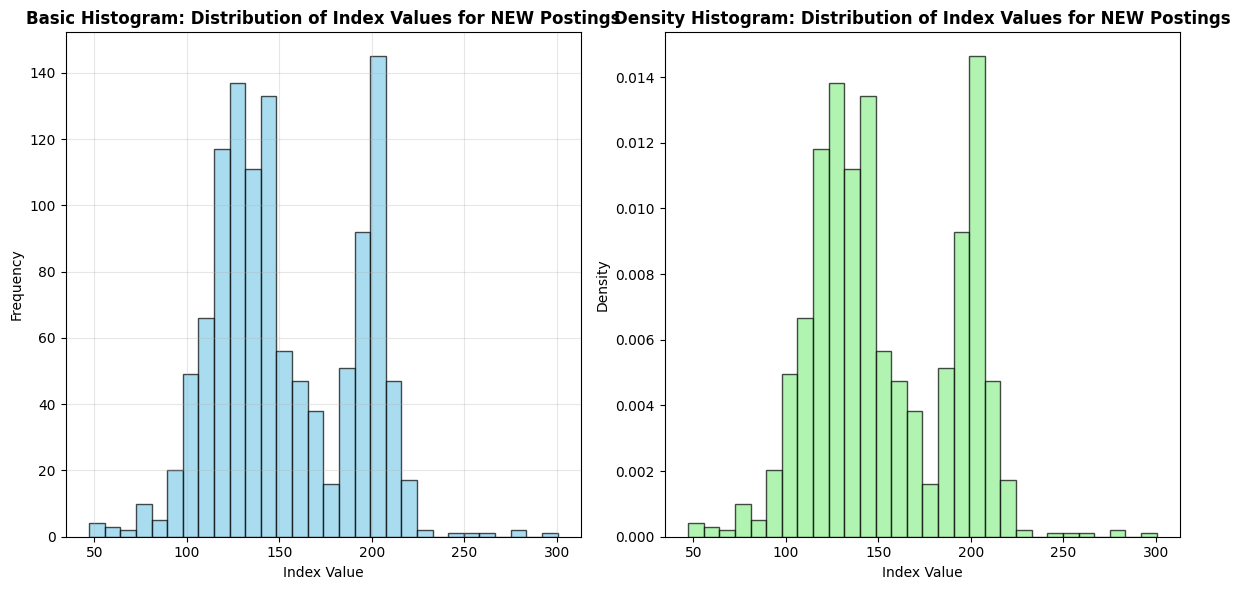

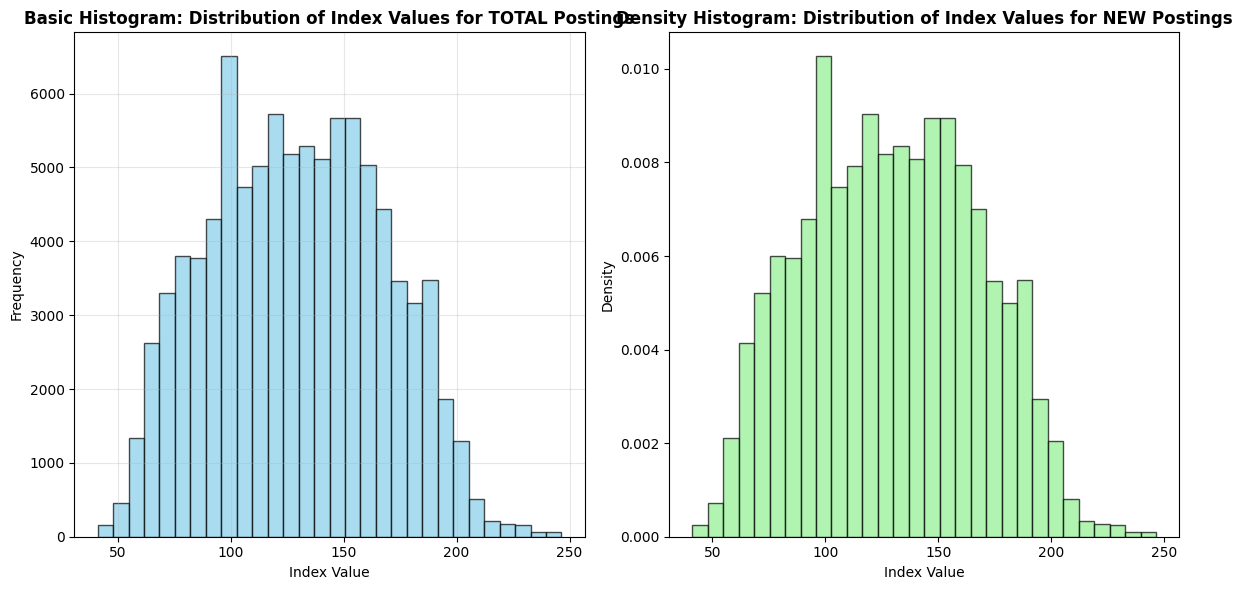

In [180]:
# Create a basic histogram using matplotlib
plt.figure(figsize=(12, 6))

# Basic histogram
plt.subplot(1, 2, 1)
plt.hist(df_cleaned['value'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Basic Histogram: Distribution of Index Values', fontsize=12, fontweight='bold')
plt.xlabel('Index Value', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.grid(True, alpha=0.3)

# Histogram with density curve
plt.subplot(1, 2, 2)
plt.hist(df_cleaned['value'], bins=30, alpha=0.7, color='lightgreen', edgecolor='black', density=True)
plt.title('Density Histogram: Distribution of Index Values', fontsize=12, fontweight='bold')
plt.xlabel('Index Value', fontsize=10)
plt.ylabel('Density', fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
#-----------------------------------------------
plt.figure(figsize=(12, 6))

# Basic histogram
plt.subplot(1, 2, 1)
plt.hist(df_cleaned_NEW['value'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Basic Histogram: Distribution of Index Values for NEW Postings', fontsize=12, fontweight='bold')
plt.xlabel('Index Value', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.grid(True, alpha=0.3)

# Histogram with density curve
plt.subplot(1, 2, 2)
plt.hist(df_cleaned_NEW['value'], bins=30, alpha=0.7, color='lightgreen', edgecolor='black', density=True)
plt.title('Density Histogram: Distribution of Index Values for NEW Postings', fontsize=12, fontweight='bold')
plt.xlabel('Index Value', fontsize=10)
plt.ylabel('Density', fontsize=10)
plt.tight_layout()
plt.show()
#-----------------------------------------------
plt.figure(figsize=(12, 6))

# Basic histogram
plt.subplot(1,2,1)
plt.hist(df_cleaned_TOTAL['value'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Basic Histogram: Distribution of Index Values for TOTAL Postings', fontsize=12, fontweight='bold')
plt.xlabel('Index Value', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.grid(True, alpha=0.3)

# Histogram with density curve
plt.subplot(1, 2, 2)
plt.hist(df_cleaned_TOTAL['value'], bins=30, alpha=0.7, color='lightgreen', edgecolor='black', density=True)
plt.title('Density Histogram: Distribution of Index Values for NEW Postings', fontsize=12, fontweight='bold')
plt.xlabel('Index Value', fontsize=10)
plt.ylabel('Density', fontsize=10)
plt.tight_layout()
plt.show()


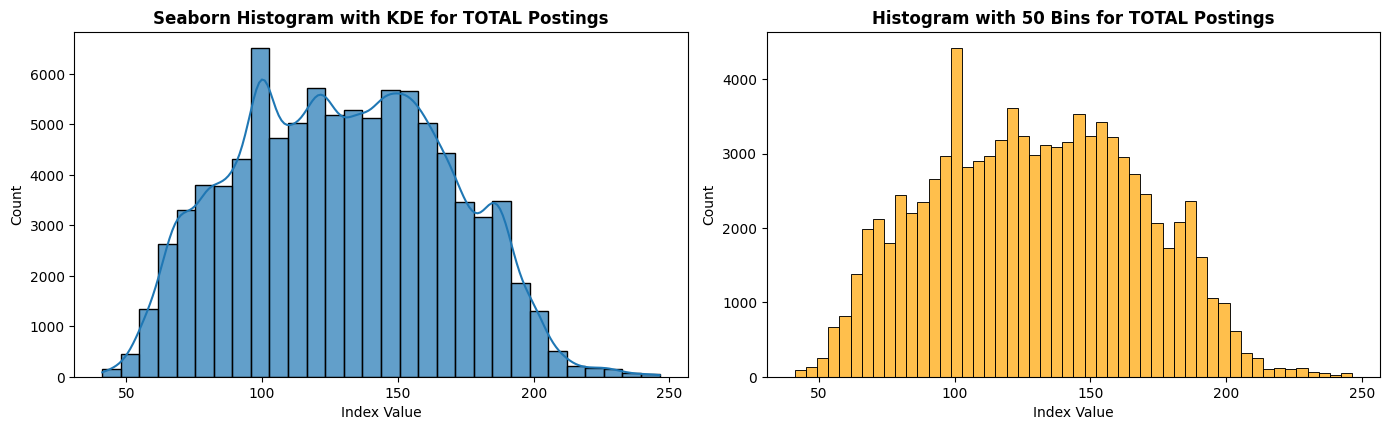

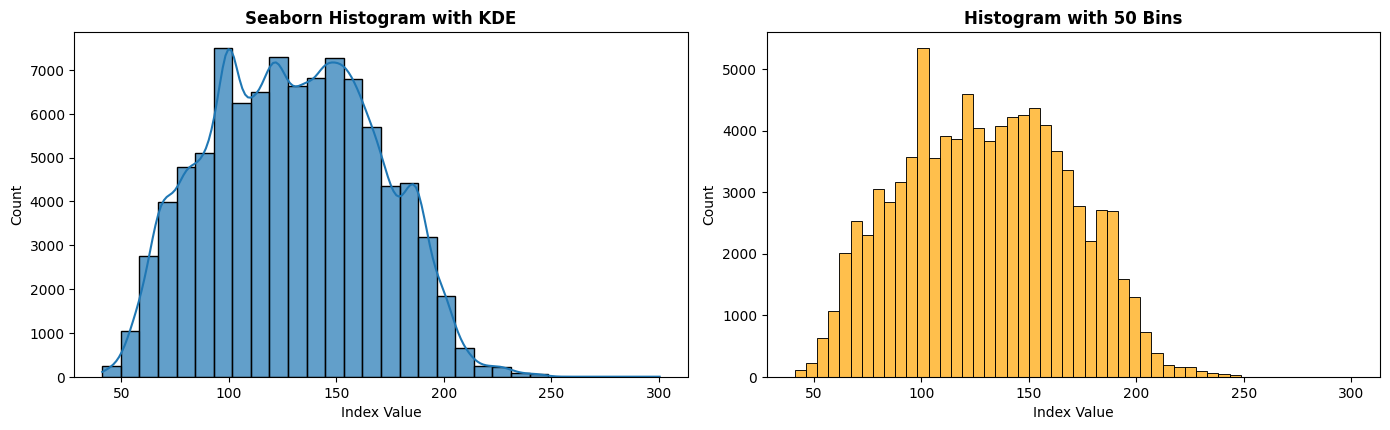

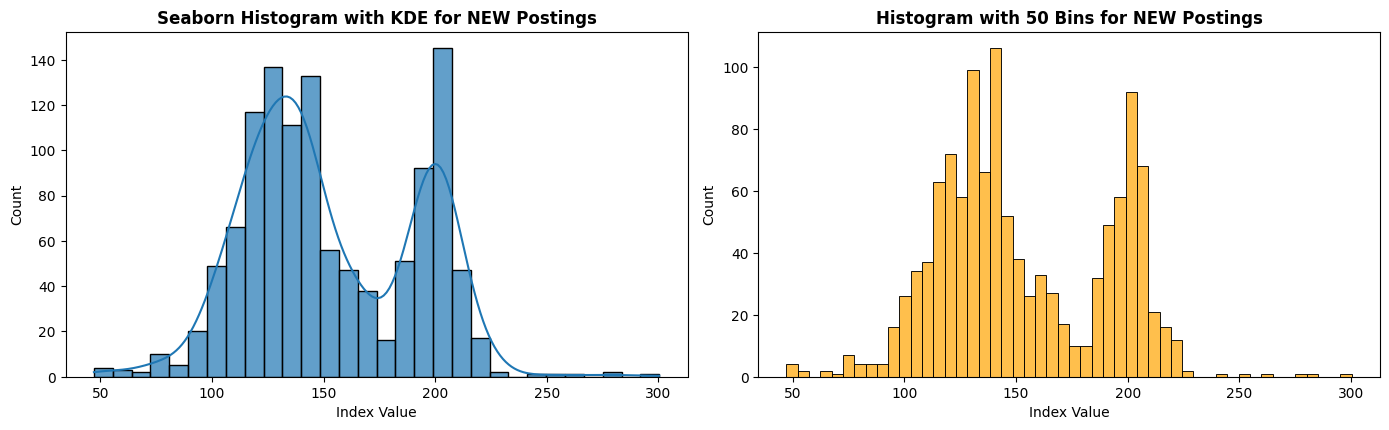

In [181]:
# Create histograms using seaborn (more beautiful and informative)
plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
sns.histplot(data=df_cleaned_TOTAL, x='value', bins=30, kde=True, alpha=0.7)
plt.title('Seaborn Histogram with KDE for TOTAL Postings', fontsize=12, fontweight='bold')
plt.xlabel('Index Value', fontsize=10)
plt.ylabel('Count', fontsize=10)

plt.subplot(2, 2, 2)
sns.histplot(data=df_cleaned_TOTAL, x='value', bins=50, alpha=0.7, color='orange')
plt.title('Histogram with 50 Bins for TOTAL Postings', fontsize=12, fontweight='bold')
plt.xlabel('Index Value', fontsize=10)
plt.ylabel('Count', fontsize=10)

plt.tight_layout()
plt.show()
#-----------------------------------------------
plt.figure(figsize=(14, 8))

# Seaborn histogram with KDE (Kernel Density Estimation)
plt.subplot(2, 2, 1)
sns.histplot(data=df_cleaned, x='value', bins=30, kde=True, alpha=0.7)
plt.title('Seaborn Histogram with KDE', fontsize=12, fontweight='bold')
plt.xlabel('Index Value', fontsize=10)
plt.ylabel('Count', fontsize=10)

# Histogram with different bin sizes
plt.subplot(2, 2, 2)
sns.histplot(data=df_cleaned, x='value', bins=50, alpha=0.7, color='orange')
plt.title('Histogram with 50 Bins', fontsize=12, fontweight='bold')
plt.xlabel('Index Value', fontsize=10)
plt.ylabel('Count', fontsize=10)

plt.tight_layout()
plt.show()
#-----------------------------------------------
plt.figure(figsize=(14, 8))

# Seaborn histogram with KDE (Kernel Density Estimation)
plt.subplot(2, 2, 1)
sns.histplot(data=df_cleaned_NEW, x='value', bins=30, kde=True, alpha=0.7)
plt.title('Seaborn Histogram with KDE for NEW Postings', fontsize=12, fontweight='bold')
plt.xlabel('Index Value', fontsize=10)
plt.ylabel('Count', fontsize=10)

plt.subplot(2, 2, 2)
sns.histplot(data=df_cleaned_NEW, x='value', bins=50, alpha=0.7, color='orange')
plt.title('Histogram with 50 Bins for NEW Postings', fontsize=12, fontweight='bold')
plt.xlabel('Index Value', fontsize=10)
plt.ylabel('Count', fontsize=10)

plt.tight_layout()
plt.show()
#-----------------------------------------------




In [182]:
# Remove data from df_cleaned_TOTAL_sorted for the date range 2024-08-24 to 2025-09-19
# First, let's check the current state of the dataframe
print("Before filtering:")
print(f"df_cleaned_TOTAL_sorted shape: {df_cleaned_TOTAL_sorted.shape}")
print(f"Date range: {df_cleaned_TOTAL_sorted['dateString'].min()} to {df_cleaned_TOTAL_sorted['dateString'].max()}")

# Convert dateString to datetime if it's not already
df_cleaned_TOTAL_sorted['dateString'] = pd.to_datetime(df_cleaned_TOTAL_sorted['dateString'])

# Define the date range to remove
start_date_to_remove = pd.to_datetime('2024-08-24')
end_date_to_remove = pd.to_datetime('2025-09-19')

# Filter out the data in the specified date range
# We want to keep data that is NOT in the range 2024-08-24 to 2025-09-19
df_cleaned_TOTAL_sorted = df_cleaned_TOTAL_sorted[
    (df_cleaned_TOTAL_sorted['dateString'] < start_date_to_remove) | 
    (df_cleaned_TOTAL_sorted['dateString'] > end_date_to_remove)
]

print("\nAfter filtering:")
print(f"df_cleaned_TOTAL_sorted shape: {df_cleaned_TOTAL_sorted.shape}")
print(f"Date range: {df_cleaned_TOTAL_sorted['dateString'].min()} to {df_cleaned_TOTAL_sorted['dateString'].max()}")

# Let's also check how many rows were removed
original_rows = 92610  # From the earlier output
filtered_rows = len(df_cleaned_TOTAL_sorted)
removed_rows = original_rows - filtered_rows

print(f"\nSummary:")
print(f"Original rows: {original_rows}")
print(f"Filtered rows: {filtered_rows}")
print(f"Removed rows: {removed_rows}")

# Display the first few rows to verify the data
print(f"\nFirst few rows of filtered data:")
print(df_cleaned_TOTAL_sorted.head())


Before filtering:
df_cleaned_TOTAL_sorted shape: (74970, 8)
Date range: 2020-02-01 00:00:00 to 2024-08-23 00:00:00

After filtering:
df_cleaned_TOTAL_sorted shape: (74970, 8)
Date range: 2020-02-01 00:00:00 to 2024-08-23 00:00:00

Summary:
Original rows: 92610
Filtered rows: 74970
Removed rows: 17640

First few rows of filtered data:
                 __typename dateString countryCode    countryName  \
0  HiringLabSectoralPosting 2020-02-01          US  United States   
1  HiringLabSectoralPosting 2020-02-01          US  United States   
2  HiringLabSectoralPosting 2020-02-01          US  United States   
3  HiringLabSectoralPosting 2020-02-01          US  United States   
4  HiringLabSectoralPosting 2020-02-01          US  United States   

                       sectorName postingType  value  \
0         accounting - Accounting       TOTAL  100.0   
1   meddr - Physicians & Surgeons       TOTAL  100.0   
2  media - Media & Communications       TOTAL  100.0   
3   medinfo - Medical Inf

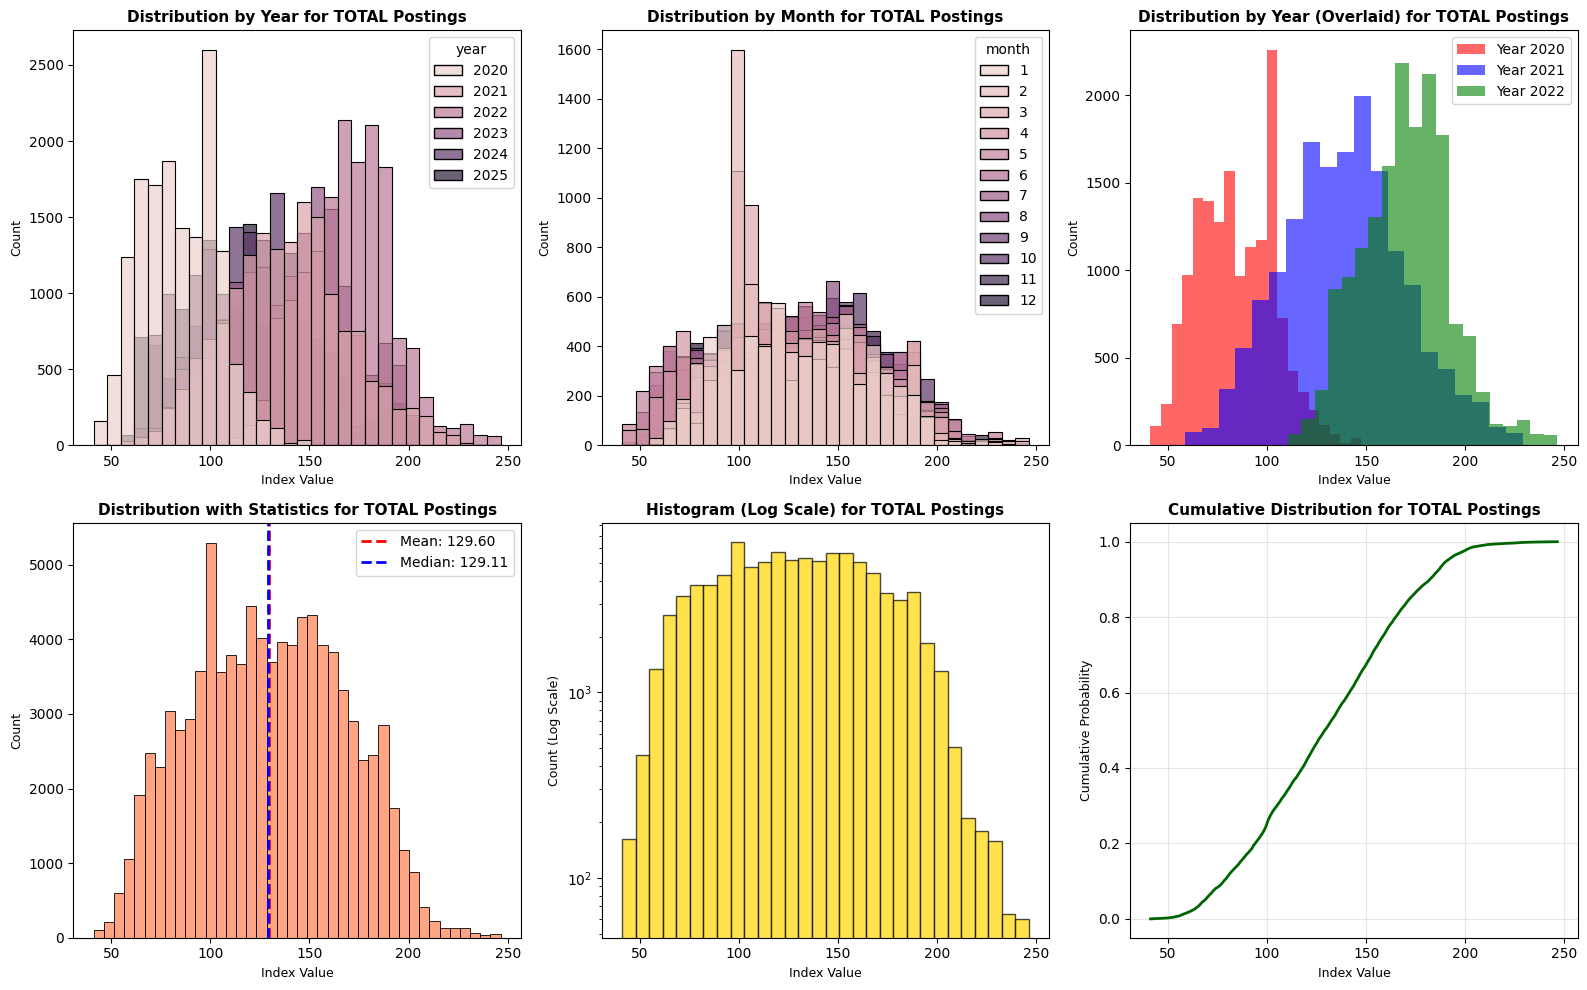

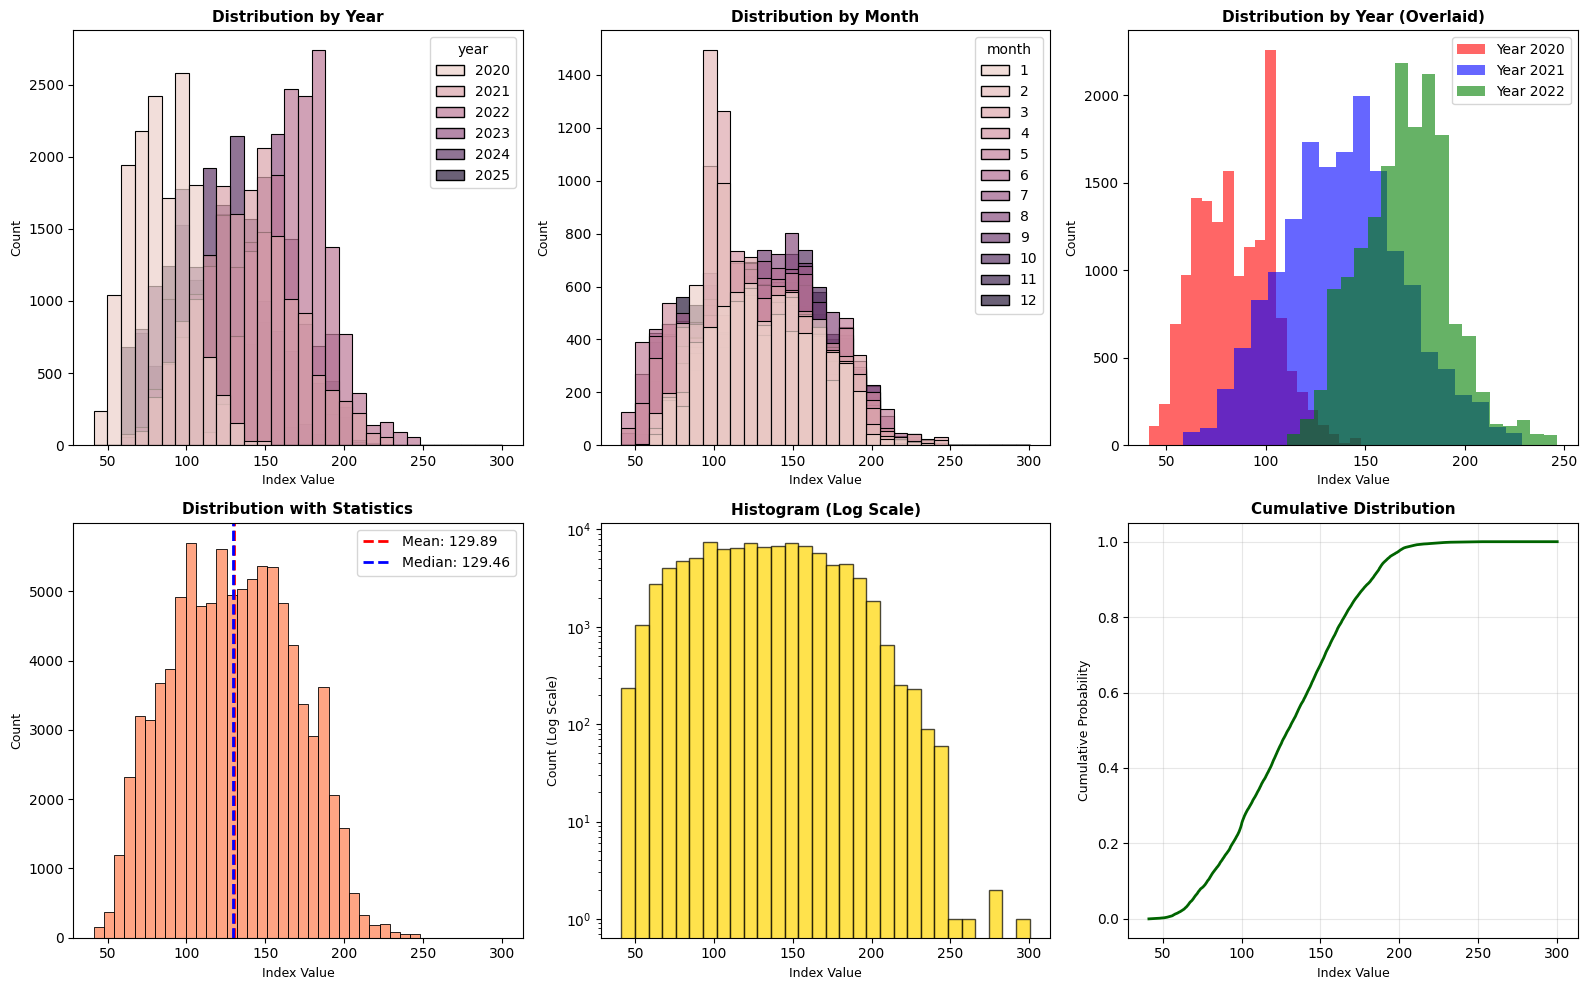

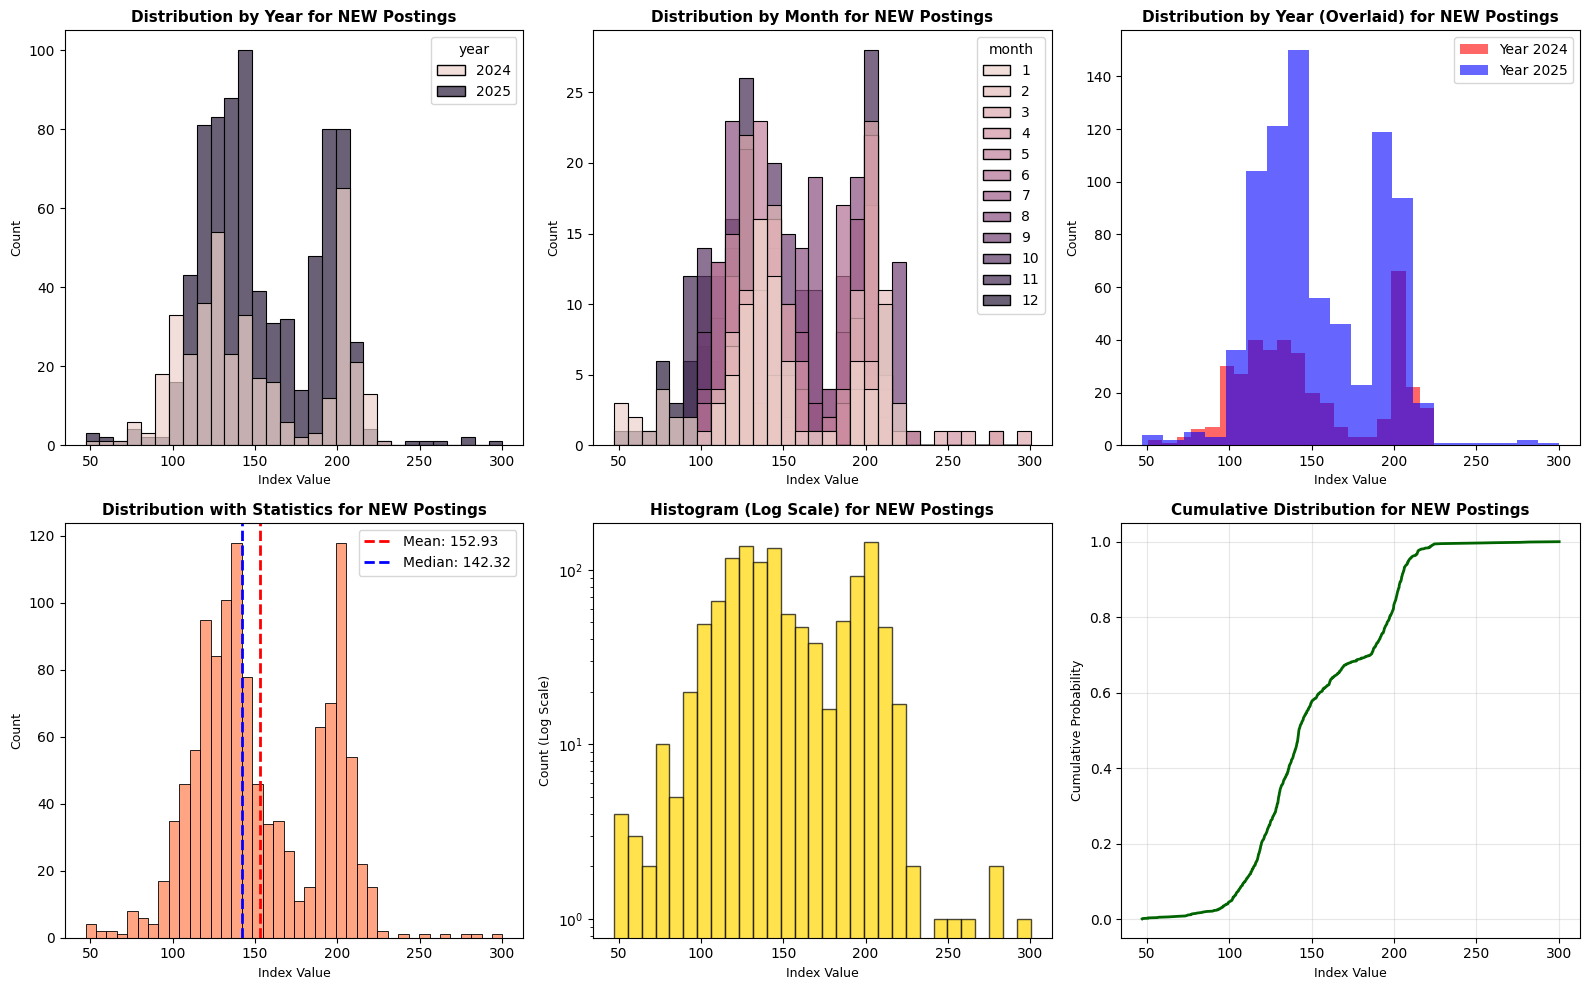

In [183]:
# Create time-based histograms (distribution by time periods)
#-----------------------------------------------
plt.figure(figsize=(16, 10))

# Histogram by year
plt.subplot(2, 3, 1)
if df_time_TOTAL['year'].nunique() > 1:
    sns.histplot(data=df_time_TOTAL, x='value', hue='year', bins=30, alpha=0.7)
    plt.title('Distribution by Year for TOTAL Postings', fontsize=11, fontweight='bold')
else:   
    sns.histplot(data=df_time_TOTAL, x='value', bins=30, alpha=0.7, color='blue')
    plt.title('Overall Distribution for TOTAL Postings', fontsize=11, fontweight='bold')
plt.xlabel('Index Value', fontsize=9)
plt.ylabel('Count', fontsize=9) 

# Histogram by month (seasonal patterns)
plt.subplot(2, 3, 2)
sns.histplot(data=df_time_TOTAL, x='value', hue='month', bins=30, alpha=0.7)
plt.title('Distribution by Month for TOTAL Postings', fontsize=11, fontweight='bold')
plt.xlabel('Index Value', fontsize=9)   
plt.ylabel('Count', fontsize=9)

# Multiple histograms in one plot (faceted)
plt.subplot(2, 3, 3)
if df_time_TOTAL['year'].nunique() > 1:
    years = sorted(df_time_TOTAL['year'].unique())
    colors = ['red', 'blue', 'green', 'orange', 'purple']   
    for i, year in enumerate(years[:3]):  # Show first 3 years
        year_data = df_time_TOTAL[df_time_TOTAL['year'] == year]['value']
        plt.hist(year_data, bins=20, alpha=0.6, label=f'Year {year}', color=colors[i])
    plt.legend()
    plt.title('Distribution by Year (Overlaid) for TOTAL Postings', fontsize=11, fontweight='bold')
else:   
    sns.histplot(data=df_time_TOTAL, x='value', bins=30, alpha=0.7, color='green')
    plt.title('Overall Distribution for TOTAL Postings', fontsize=11, fontweight='bold')
plt.xlabel('Index Value', fontsize=9)
plt.ylabel('Count', fontsize=9) 

# Distribution with statistical information
plt.subplot(2, 3, 4)
sns.histplot(data=df_time_TOTAL, x='value', bins=40, alpha=0.7, color='coral')
# Add mean and median lines
mean_val = df_time_TOTAL['value'].mean()
median_val = df_time_TOTAL['value'].median()      
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='blue', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
plt.legend()
plt.title('Distribution with Statistics for TOTAL Postings', fontsize=11, fontweight='bold')
plt.xlabel('Index Value', fontsize=9)
plt.ylabel('Count', fontsize=9) 

# Log scale histogram (if data has wide range)
plt.subplot(2, 3, 5)
plt.hist(df_time_TOTAL['value'], bins=30, alpha=0.7, color='gold', edgecolor='black')
plt.yscale('log')  # Log scale for y-axis
plt.title('Histogram (Log Scale) for TOTAL Postings', fontsize=11, fontweight='bold')
plt.xlabel('Index Value', fontsize=9)   
plt.ylabel('Count (Log Scale)', fontsize=9) 

# Cumulative distribution
plt.subplot(2, 3, 6)
sorted_values = np.sort(df_time_TOTAL['value'])
cumulative = np.arange(1, len(sorted_values) + 1) / len(sorted_values)
plt.plot(sorted_values, cumulative, linewidth=2, color='darkgreen')
plt.title('Cumulative Distribution for TOTAL Postings', fontsize=11, fontweight='bold')
plt.xlabel('Index Value', fontsize=9)
plt.ylabel('Cumulative Probability', fontsize=9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
#------------------------------------------------------------------
# First, let's prepare time-based data
plt.figure(figsize=(16, 10))

# Histogram by year
plt.subplot(2, 3, 1)
if df_time['year'].nunique() > 1:
    sns.histplot(data=df_time, x='value', hue='year', bins=30, alpha=0.7)
    plt.title('Distribution by Year', fontsize=11, fontweight='bold')
else:
    sns.histplot(data=df_time, x='value', bins=30, alpha=0.7, color='blue')
    plt.title('Overall Distribution', fontsize=11, fontweight='bold')
plt.xlabel('Index Value', fontsize=9)
plt.ylabel('Count', fontsize=9)

# Histogram by month (seasonal patterns)
plt.subplot(2, 3, 2)
sns.histplot(data=df_time, x='value', hue='month', bins=30, alpha=0.7)
plt.title('Distribution by Month', fontsize=11, fontweight='bold')
plt.xlabel('Index Value', fontsize=9)
plt.ylabel('Count', fontsize=9)

# Multiple histograms in one plot (faceted)
plt.subplot(2, 3, 3)
if df_time['year'].nunique() > 1:
    # Show distribution for each year separately
    years = sorted(df_time['year'].unique())
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    for i, year in enumerate(years[:3]):  # Show first 3 years
        year_data = df_time[df_time['year'] == year]['value']
        plt.hist(year_data, bins=20, alpha=0.6, label=f'Year {year}', color=colors[i])
    plt.legend()
    plt.title('Distribution by Year (Overlaid)', fontsize=11, fontweight='bold')
else:
    sns.histplot(data=df_time, x='value', bins=30, alpha=0.7, color='green')
    plt.title('Overall Distribution', fontsize=11, fontweight='bold')
plt.xlabel('Index Value', fontsize=9)
plt.ylabel('Count', fontsize=9)

# Distribution with statistical information
plt.subplot(2, 3, 4)
sns.histplot(data=df_time, x='value', bins=40, alpha=0.7, color='coral')
# Add mean and median lines
mean_val = df_time['value'].mean()
median_val = df_time['value'].median()
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='blue', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
plt.legend()
plt.title('Distribution with Statistics', fontsize=11, fontweight='bold')
plt.xlabel('Index Value', fontsize=9)
plt.ylabel('Count', fontsize=9)

# Log scale histogram (if data has wide range)
plt.subplot(2, 3, 5)
plt.hist(df_time['value'], bins=30, alpha=0.7, color='gold', edgecolor='black')
plt.yscale('log')  # Log scale for y-axis
plt.title('Histogram (Log Scale)', fontsize=11, fontweight='bold')
plt.xlabel('Index Value', fontsize=9)
plt.ylabel('Count (Log Scale)', fontsize=9)

# Cumulative distribution
plt.subplot(2, 3, 6)
sorted_values = np.sort(df_time['value'])
cumulative = np.arange(1, len(sorted_values) + 1) / len(sorted_values)
plt.plot(sorted_values, cumulative, linewidth=2, color='darkgreen')
plt.title('Cumulative Distribution', fontsize=11, fontweight='bold')
plt.xlabel('Index Value', fontsize=9)
plt.ylabel('Cumulative Probability', fontsize=9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
#-----------------------------------------------
plt.figure(figsize=(16, 10))

# Histogram by year
plt.subplot(2, 3, 1)
if df_time_NEW['year'].nunique() > 1:
    sns.histplot(data=df_time_NEW, x='value', hue='year', bins=30, alpha=0.7)
    plt.title('Distribution by Year for NEW Postings', fontsize=11, fontweight='bold')  
else:
    sns.histplot(data=df_time_NEW, x='value', bins=30, alpha=0.7, color='blue')
    plt.title('Overall Distribution for NEW Postings', fontsize=11, fontweight='bold')
plt.xlabel('Index Value', fontsize=9)
plt.ylabel('Count', fontsize=9) 

# Histogram by month (seasonal patterns)
plt.subplot(2, 3, 2)
sns.histplot(data=df_time_NEW, x='value', hue='month', bins=30, alpha=0.7)
plt.title('Distribution by Month for NEW Postings', fontsize=11, fontweight='bold')
plt.xlabel('Index Value', fontsize=9)   
plt.ylabel('Count', fontsize=9)

# Multiple histograms in one plot (faceted)
plt.subplot(2, 3, 3)
if df_time_NEW['year'].nunique() > 1:
    years = sorted(df_time_NEW['year'].unique())
    colors = ['red', 'blue', 'green', 'orange', 'purple']   
    for i, year in enumerate(years[:3]):  # Show first 3 years
        year_data = df_time_NEW[df_time_NEW['year'] == year]['value']
        plt.hist(year_data, bins=20, alpha=0.6, label=f'Year {year}', color=colors[i])
    plt.legend()
    plt.title('Distribution by Year (Overlaid) for NEW Postings', fontsize=11, fontweight='bold')
else:   
    sns.histplot(data=df_time_NEW, x='value', bins=30, alpha=0.7, color='green')
    plt.title('Overall Distribution for NEW Postings', fontsize=11, fontweight='bold')
plt.xlabel('Index Value', fontsize=9)
plt.ylabel('Count', fontsize=9) 

# Distribution with statistical information
plt.subplot(2, 3, 4)
sns.histplot(data=df_time_NEW, x='value', bins=40, alpha=0.7, color='coral')
# Add mean and median lines
mean_val = df_time_NEW['value'].mean()
median_val = df_time_NEW['value'].median()  
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='blue', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
plt.legend()
plt.title('Distribution with Statistics for NEW Postings', fontsize=11, fontweight='bold')
plt.xlabel('Index Value', fontsize=9)
plt.ylabel('Count', fontsize=9) 

# Log scale histogram (if data has wide range)
plt.subplot(2, 3, 5)
plt.hist(df_time_NEW['value'], bins=30, alpha=0.7, color='gold', edgecolor='black')
plt.yscale('log')  # Log scale for y-axis
plt.title('Histogram (Log Scale) for NEW Postings', fontsize=11, fontweight='bold')
plt.xlabel('Index Value', fontsize=9)
plt.ylabel('Count (Log Scale)', fontsize=9) 

# Cumulative distribution
plt.subplot(2, 3, 6)
sorted_values = np.sort(df_time_NEW['value'])
cumulative = np.arange(1, len(sorted_values) + 1) / len(sorted_values)
plt.plot(sorted_values, cumulative, linewidth=2, color='darkgreen')
plt.title('Cumulative Distribution for NEW Postings', fontsize=11, fontweight='bold')
plt.xlabel('Index Value', fontsize=9)
plt.ylabel('Cumulative Probability', fontsize=9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


